In [2]:
from rep_lr.py_datasets import TrainDataset
import pickle
import argparse
dataset_args = argparse.Namespace(slice_len=1024)

In [3]:
ID_class_dict = {}
for i in range(16):
    this_key = 'Radio'+str(i)
    ID_class_dict[this_key] = i
print(ID_class_dict)

{'Radio0': 0, 'Radio1': 1, 'Radio2': 2, 'Radio3': 3, 'Radio4': 4, 'Radio5': 5, 'Radio6': 6, 'Radio7': 7, 'Radio8': 8, 'Radio9': 9, 'Radio10': 10, 'Radio11': 11, 'Radio12': 12, 'Radio13': 13, 'Radio14': 14, 'Radio15': 15}


In [4]:
pkl_file_path = "/home/hofmann/Documents/projects/RepresentationLearning/dataset/rf_partition_dict_0.5.pkl"

with open(pkl_file_path,'rb') as f:

    content = pickle.load(f)

train_list = content['train']
val_list = content['val']
max_cfo = content['max_cfo']

In [5]:
train_dataset = TrainDataset(train_list, ID_class_dict,dataset_args,max_cfo, )

In [12]:
RF_X, RF_y, CFO_X, CFO_y, Channel_X, Channel_y, file_path = train_dataset[0]

In [24]:
len(train_dataset)

91323

In [29]:
import random 

In [30]:
random.randint()

TypeError: Random.randint() missing 2 required positional arguments: 'a' and 'b'

In [6]:
fraction_to_use=0.4
num_train = int(len(train_dataset)*fraction_to_use)

In [18]:
import random

train_idx = [random.randint(0,num_train) for _ in range(num_train)]


X=[]
Y=[]

for i in train_idx:
    RF_X, RF_y, CFO_X, CFO_y, Channel_X, Channel_y, file_path = train_dataset[i]
    X.append(CFO_X)
    Y.append(CFO_y)
    
    
    
    








In [36]:
X[0].shape

torch.Size([2, 160])

In [17]:
len(Y)

9132

In [19]:
Y = [y*content['max_cfo'] for y in Y]

In [20]:
len(Y)

36529

Generating sample data as PyTorch Tensors...

Preprocessing data (converting torch to numpy)...
Shape of X after reshaping and conversion: (36529, 320)
Shape of Y after conversion: (36529,)

Finding best hyperparameters with GridSearchCV...
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Best parameters found: {'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 80}
Model fitting complete with best parameters.
Plotting the best decision tree...


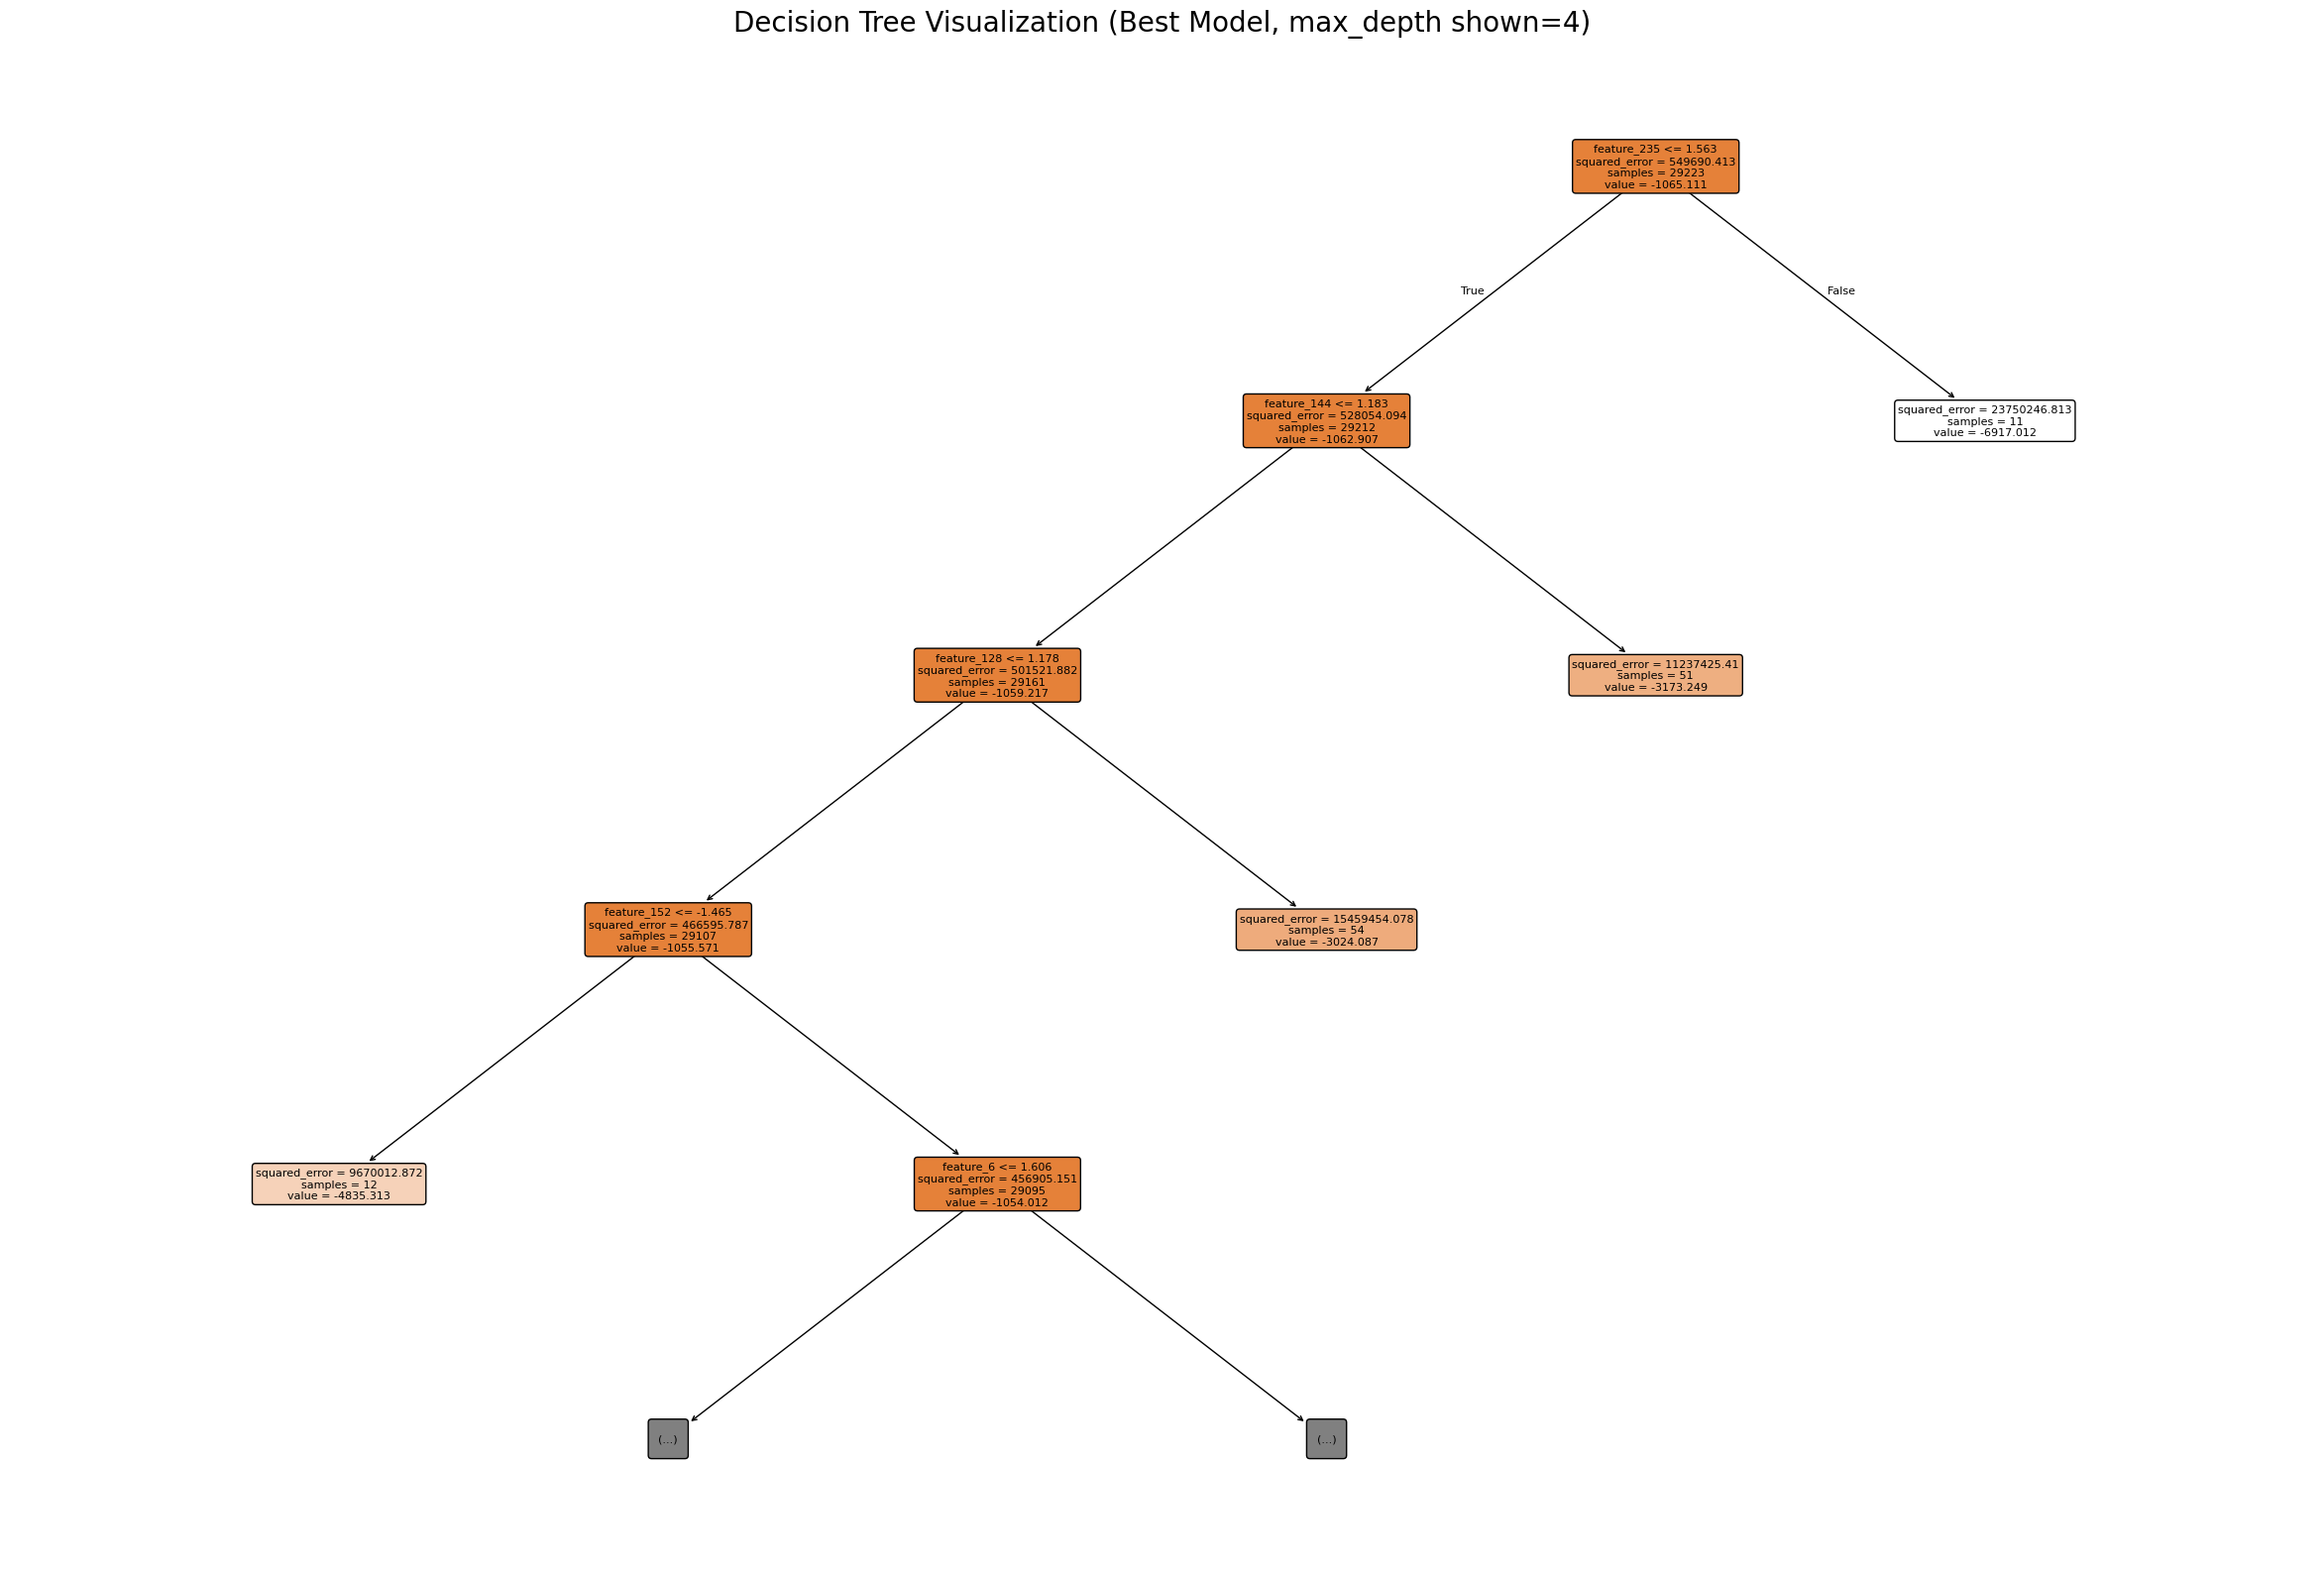


Analyzing feature importances from the best model...
Features with importance > 0.01:
  - Feature 6: Importance = 0.1384
  - Feature 128: Importance = 0.1828
  - Feature 144: Importance = 0.1991
  - Feature 152: Importance = 0.1501
  - Feature 235: Importance = 0.3297


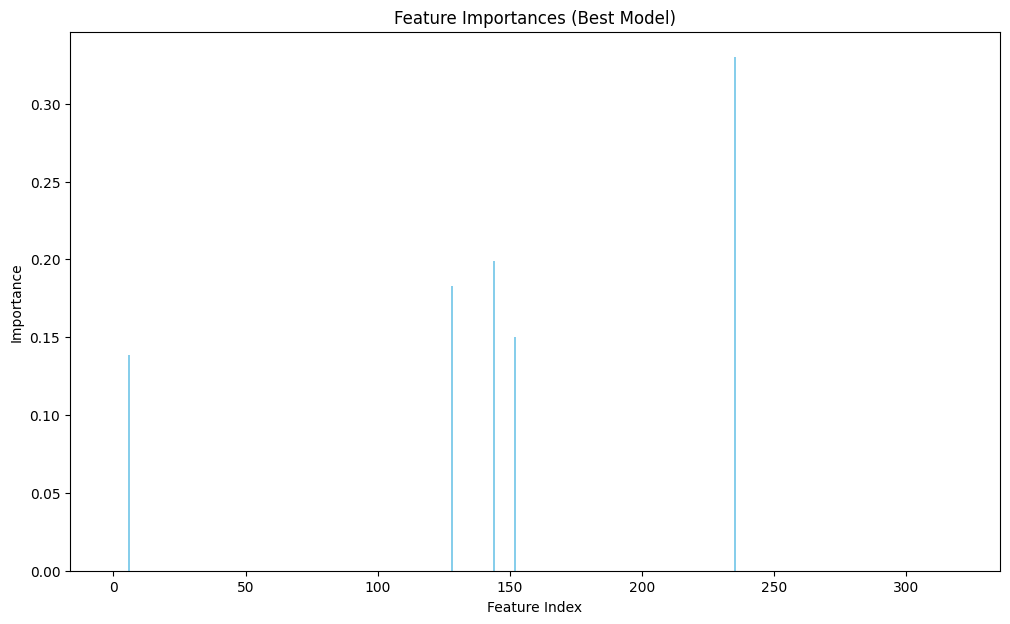


Enhanced Leaf Node Analysis...
Leaf with lowest mean Y: ID=10, Mean Y=-6527.242, Samples=12
Leaf with highest mean Y: ID=6, Mean Y=-1055.337, Samples=36356


/tmp/ipykernel_4559/3316088967.py:143: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([Y, y_in_lowest_leaf, y_in_highest_leaf],


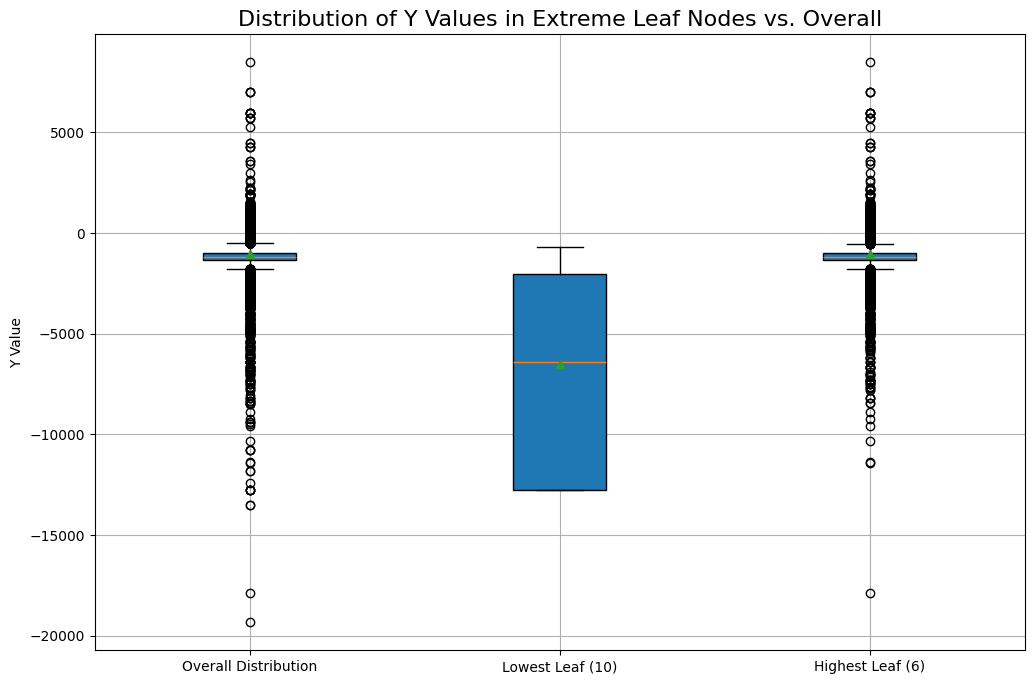

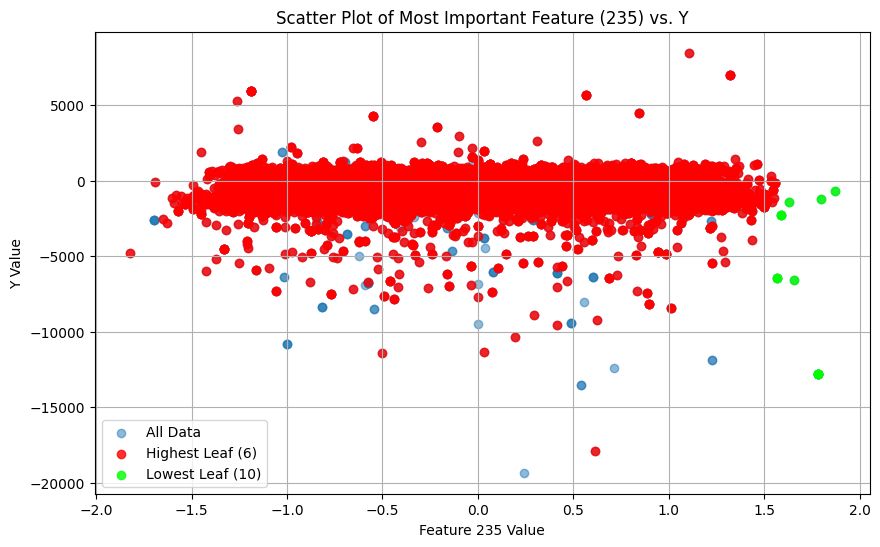


--- Finding the 'Golden Rule' for the Outlier Leaf ---
Rules for Leaf ID 10:
  Node 0: feature_235 > 1.563


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
import torch # Import the torch library

# --- 1. Generate Sample Data (as PyTorch Tensors) ---
# This section creates dummy data as a list of PyTorch tensors,
# matching your description.
# In your real code, you would load your X_list and Y_list here.
print("Generating sample data as PyTorch Tensors...")
num_samples = len(X)
# X is a list of 2x160 tensors.
X_list = X
# Y is a list of 1x1 scalar tensors.
# We'll create some outliers in Y for demonstration purposes.
Y_list = Y



# --- FIX: Add an explicit check for consistent lengths ---
# This will catch the error early and provide a clear message.
# Before proceeding, ensure that your input X_list and Y_list have the same number of samples.
assert len(X_list) == len(Y_list), (
    f"Data loading error: X_list has {len(X_list)} samples, "
    f"but Y_list has {len(Y_list)} samples. They must have the same length."
)


# --- 2. Preprocess the Data (Convert Tensors to NumPy) ---
# Reshape each 2x160 tensor in X into a 1x320 vector and convert to NumPy.
print("\nPreprocessing data (converting torch to numpy)...")

# Check if the element is a tensor before trying to convert it.
X_reshaped = np.array([
    x.reshape(320).cpu().numpy() if isinstance(x, torch.Tensor) else x.reshape(320)
    for x in X_list
])

# Use .item() to extract the scalar value from tensors.
# This prevents the ValueError by ensuring all elements are scalars before creating the array.
Y = np.array([
    y.item() if isinstance(y, torch.Tensor) else y
    for y in Y_list
])

print(f"Shape of X after reshaping and conversion: {X_reshaped.shape}")
print(f"Shape of Y after conversion: {Y.shape}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, Y, test_size=0.2, random_state=42
)

# --- 3. IMPROVEMENT: Hyperparameter Tuning with GridSearchCV ---
print("\nFinding best hyperparameters with GridSearchCV...")
# Define the parameter grid to search
param_grid = {
    'max_depth': [3, 4, 5, 7, 10],
    'min_samples_leaf': [10, 20, 40, 50],
    'min_samples_split': [20, 40, 80]
}

# Create a decision tree regressor object
dt = DecisionTreeRegressor(random_state=42)

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, 
                           cv=3, n_jobs=-1, verbose=1, scoring='neg_mean_squared_error')

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
print(f"Best parameters found: {grid_search.best_params_}")
decision_tree = grid_search.best_estimator_ # This is our new, optimized tree
print("Model fitting complete with best parameters.")


# --- 4. Visualize the Best Decision Tree ---
print("Plotting the best decision tree...")
plt.figure(figsize=(30, 20))
plot_tree(
    decision_tree,
    filled=True,
    feature_names=[f'feature_{i}' for i in range(X_reshaped.shape[1])],
    rounded=True,
    fontsize=8,
    max_depth=4 # Limit plot depth for readability
)
plt.title(f"Decision Tree Visualization (Best Model, max_depth shown=4)", fontsize=20)
plt.show()

# --- 5. Analyze Feature Importances ---
print("\nAnalyzing feature importances from the best model...")
importances = decision_tree.feature_importances_
important_features_indices = np.where(importances > 0.01)[0] # Features with >1% importance

print(f"Features with importance > 0.01:")
for i in important_features_indices:
    print(f"  - Feature {i}: Importance = {importances[i]:.4f}")

plt.figure(figsize=(12, 7))
plt.bar(range(len(importances)), importances, color='skyblue')
plt.title('Feature Importances (Best Model)')
plt.xlabel('Feature Index')
plt.ylabel('Importance')
plt.show()


# --- 6. IMPROVEMENT: Enhanced Leaf Node Analysis ---
print("\nEnhanced Leaf Node Analysis...")
# Get the leaf node id for each sample in the full dataset
leaf_ids = decision_tree.apply(X_reshaped)
unique_leaves = np.unique(leaf_ids)

leaf_stats = []
for leaf in unique_leaves:
    y_values_in_leaf = Y[leaf_ids == leaf]
    if len(y_values_in_leaf) > 0:
        leaf_stats.append({
            'leaf_id': leaf,
            'mean_y': np.mean(y_values_in_leaf),
            'sample_count': len(y_values_in_leaf)
        })

# Sort leaves by their mean Y value
leaf_stats.sort(key=lambda x: x['mean_y'])

# Identify the leaves with the lowest and highest mean Y
lowest_y_leaf = leaf_stats[0]
highest_y_leaf = leaf_stats[-1]

print(f"Leaf with lowest mean Y: ID={lowest_y_leaf['leaf_id']}, Mean Y={lowest_y_leaf['mean_y']:.3f}, Samples={lowest_y_leaf['sample_count']}")
print(f"Leaf with highest mean Y: ID={highest_y_leaf['leaf_id']}, Mean Y={highest_y_leaf['mean_y']:.3f}, Samples={highest_y_leaf['sample_count']}")

# Get the actual Y values for these specific leaves
y_in_lowest_leaf = Y[leaf_ids == lowest_y_leaf['leaf_id']]
y_in_highest_leaf = Y[leaf_ids == highest_y_leaf['leaf_id']]

# Create a boxplot to visualize the distributions
plt.figure(figsize=(12, 8))
plt.boxplot([Y, y_in_lowest_leaf, y_in_highest_leaf],
            labels=['Overall Distribution', f"Lowest Leaf ({lowest_y_leaf['leaf_id']})", f"Highest Leaf ({highest_y_leaf['leaf_id']})"],
            patch_artist=True,
            showmeans=True)
plt.title('Distribution of Y Values in Extreme Leaf Nodes vs. Overall', fontsize=16)
plt.ylabel('Y Value')
plt.grid(True)
plt.show()

# --- 7. Scatter plot of a key feature vs. Y ---
most_important_feature_idx = np.argmax(importances)
plt.figure(figsize=(10, 6))
plt.scatter(X_reshaped[:, most_important_feature_idx], Y, alpha=0.5, label='All Data')

# Highlight the samples from the highest and lowest leaves
plt.scatter(X_reshaped[leaf_ids == highest_y_leaf['leaf_id'], most_important_feature_idx], 
            Y[leaf_ids == highest_y_leaf['leaf_id']], 
            color='red', alpha=0.8, label=f"Highest Leaf ({highest_y_leaf['leaf_id']})")
            
plt.scatter(X_reshaped[leaf_ids == lowest_y_leaf['leaf_id'], most_important_feature_idx], 
            Y[leaf_ids == lowest_y_leaf['leaf_id']], 
            color='lime', alpha=0.8, label=f"Lowest Leaf ({lowest_y_leaf['leaf_id']})")

plt.title(f'Scatter Plot of Most Important Feature ({most_important_feature_idx}) vs. Y')
plt.xlabel(f'Feature {most_important_feature_idx} Value')
plt.ylabel('Y Value')
plt.grid(True)
plt.legend()
plt.show()

# --- 8. NEW: Extract and Display the Decision Path for an Outlier Leaf ---
print("\n--- Finding the 'Golden Rule' for the Outlier Leaf ---")

# We use the ID of the leaf with the lowest mean Y value identified in section 6
target_leaf_id = lowest_y_leaf['leaf_id']

# Get the feature and threshold information from the trained tree
tree = decision_tree.tree_
feature_names = [f'feature_{i}' for i in range(X_reshaped.shape[1])]

# Find the decision path for a sample in the target leaf
# First, find the index of the first sample that belongs to our target leaf
try:
    sample_index = np.where(leaf_ids == target_leaf_id)[0][0]
    
    # Get the decision path for this sample
    node_indicator = decision_tree.decision_path(X_reshaped[sample_index:sample_index+1])
    leaf_id = decision_tree.apply(X_reshaped[sample_index:sample_index+1])
    
    node_index = node_indicator.indices[node_indicator.indptr[0]:node_indicator.indptr[1]]
    
    print(f'Rules for Leaf ID {target_leaf_id}:')
    for node_id in node_index:
        # Continue to the next node if it is a leaf node
        if leaf_id[0] == node_id:
            continue
    
        # Check if the feature of the node is the same as the feature of the parent
        if tree.children_left[node_id] != tree.children_right[node_id]:
            feature_idx = tree.feature[node_id]
            threshold = tree.threshold[node_id]
            
            # Determine if the sample went left or right
            if X_reshaped[sample_index, feature_idx] <= threshold:
                inequality_sign = "<="
            else:
                inequality_sign = ">"
    
            print(f"  Node {node_id}: {feature_names[feature_idx]} {inequality_sign} {threshold:.3f}")

except IndexError:
    print(f"Could not find a sample for leaf ID {target_leaf_id}. This can happen if the leaf only appears in the test set.")

except Exception as e:
    print(f"An error occurred while finding the decision path: {e}")



In [ ]:
#X-> list of tensors, each shape 2x160
#Y-> list of Tensor of shape 1x1
#len(X)-> 9132



Preprocessing data (converting torch to numpy)...
Shape of X after reshaping and conversion: (9132, 320)
Shape of Y after conversion: (9132,)

Fitting Decision Tree Regressor...
Model fitting complete.
Plotting the decision tree...


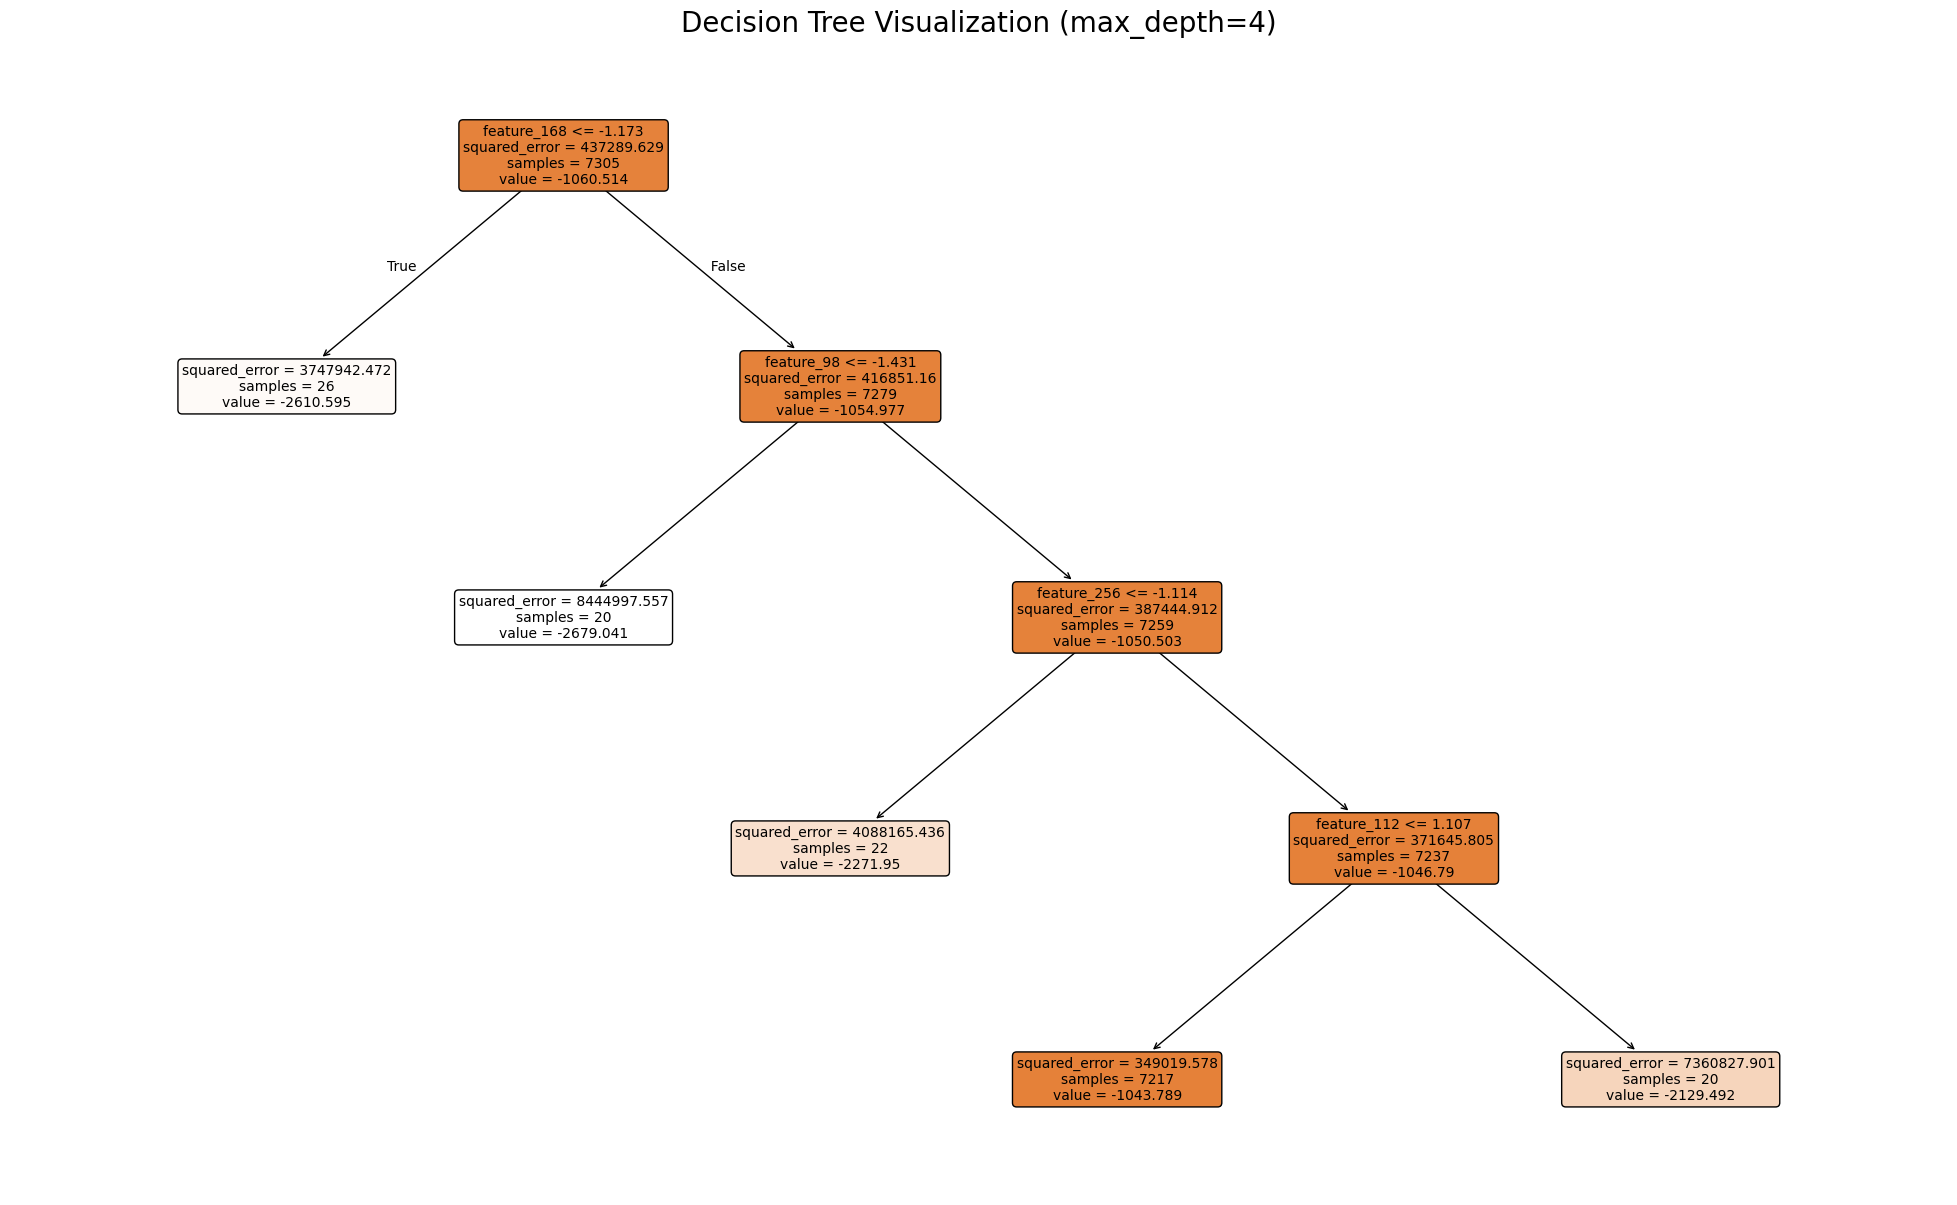


Analyzing feature importances...
Top 10 most important features:
  - Feature 112: Importance = 0.1367
  - Feature 256: Importance = 0.1914
  - Feature 98: Importance = 0.3075
  - Feature 168: Importance = 0.3645


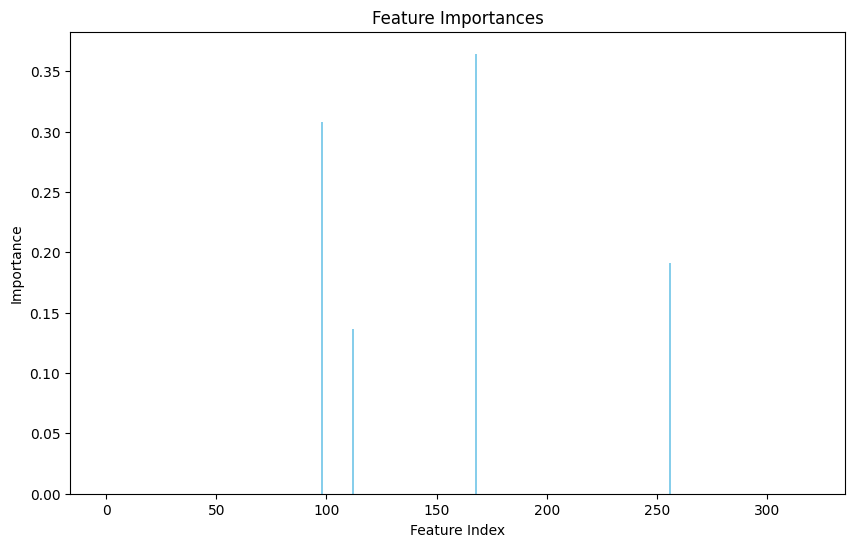


Analyzing leaf nodes...
Leaf Node Analysis:


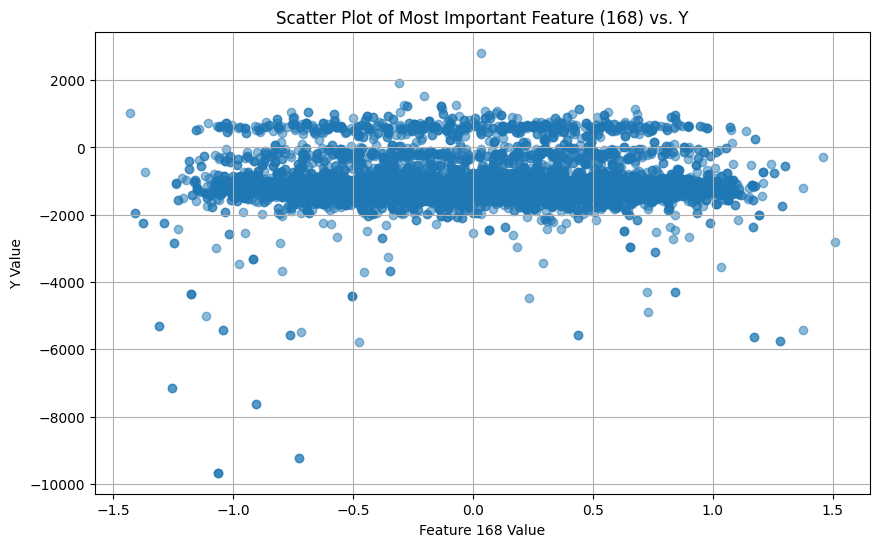

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
import torch # Import the torch library


# X is a list of 2x160 tensors.
X_list = X
# Y is a list of 1x1 scalar tensors.
# We'll create some outliers in Y for demonstration purposes.
Y_list = Y



# --- 2. Preprocess the Data (Convert Tensors to NumPy) ---
# Reshape each 2x160 tensor in X into a 1x320 vector and convert to NumPy.
# scikit-learn models require NumPy arrays as input.
print("\nPreprocessing data (converting torch to numpy)...")

# FIX: Check if the element is a tensor before trying to convert it.
# This handles cases where the list might contain mixed types (tensors and numpy arrays).
X_reshaped = np.array([
    x.reshape(320).cpu().numpy() if isinstance(x, torch.Tensor) else x.reshape(320)
    for x in X_list
])

# FIX: Check if the element is a tensor before calling .cpu().numpy().
# This resolves the AttributeError.
Y = np.array([
    y.cpu().numpy() if isinstance(y, torch.Tensor) else y
    for y in Y_list
]).ravel()


print(f"Shape of X after reshaping and conversion: {X_reshaped.shape}")
print(f"Shape of Y after conversion: {Y.shape}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, Y, test_size=0.2, random_state=42
)

# --- 3. Fit a Decision Tree Regressor ---
# We'll set a max_depth to keep the tree interpretable.
# You can tune this parameter based on your needs.
print("\nFitting Decision Tree Regressor...")
decision_tree = DecisionTreeRegressor(max_depth=4, random_state=42, min_samples_leaf=20)
decision_tree.fit(X_train, y_train)
print("Model fitting complete.")

# --- 4. Visualize the Decision Tree ---
# This plot will show the splits the model learned.
print("Plotting the decision tree...")
plt.figure(figsize=(25, 15))
plot_tree(
    decision_tree,
    filled=True,
    feature_names=[f'feature_{i}' for i in range(X_reshaped.shape[1])],
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization (max_depth=4)", fontsize=20)
plt.show()

# --- 5. Analyze Feature Importances ---
# This helps identify which of the 320 features are most influential.
print("\nAnalyzing feature importances...")
importances = decision_tree.feature_importances_
# Get the indices of the most important features
important_features_indices = np.argsort(importances)[-10:] # Top 10 features

print("Top 10 most important features:")
for i in important_features_indices:
    if importances[i] > 0:
        print(f"  - Feature {i}: Importance = {importances[i]:.4f}")

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances, color='skyblue')
plt.title('Feature Importances')
plt.xlabel('Feature Index')
plt.ylabel('Importance')
plt.show()


# --- 6. Analyze Leaf Nodes to Find Outliers ---
# We can inspect the leaf nodes to find partitions with high average Y values.
print("\nAnalyzing leaf nodes...")
leaf_ids = decision_tree.apply(X_reshaped)
unique_leaves = np.unique(leaf_ids)

print("Leaf Node Analysis:")
for leaf in unique_leaves:
    # Find all samples that fall into this leaf
    samples_in_leaf = X_reshaped[leaf_ids == leaf]
    y_values_in_leaf = Y[leaf_ids == leaf]

    if len(y_values_in_leaf) > 0:
        avg_y = np.mean(y_values_in_leaf)
        num_samples_in_leaf = len(y_values_in_leaf)
        
        # We can set a threshold to identify leaves with high average Y values (potential outliers)
        if avg_y > 40: # Example threshold
            print(f"  - Leaf Node {leaf}:")
            print(f"    - Number of samples: {num_samples_in_leaf}")
            print(f"    - Average Y value: {avg_y:.2f} (Potential outlier group)")
            
            # You can further analyze the characteristics of samples_in_leaf here
            # For example, what are the common feature values for these samples?
            # print(np.mean(samples_in_leaf, axis=0))


# --- 7. Scatter plot of a key feature vs. Y ---
# Let's use the most important feature for a scatter plot
most_important_feature_idx = important_features_indices[-1]
plt.figure(figsize=(10, 6))
plt.scatter(X_reshaped[:, most_important_feature_idx], Y, alpha=0.5)
plt.title(f'Scatter Plot of Most Important Feature ({most_important_feature_idx}) vs. Y')
plt.xlabel(f'Feature {most_important_feature_idx} Value')
plt.ylabel('Y Value')
plt.grid(True)
plt.show()



Preprocessing data (converting torch to numpy)...
Shape of X after reshaping and conversion: (36529, 320)
Shape of Y after conversion: (36529,)

Finding best hyperparameters with GridSearchCV...
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Best parameters found: {'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 80}
Model fitting complete with best parameters.
Plotting the best decision tree...


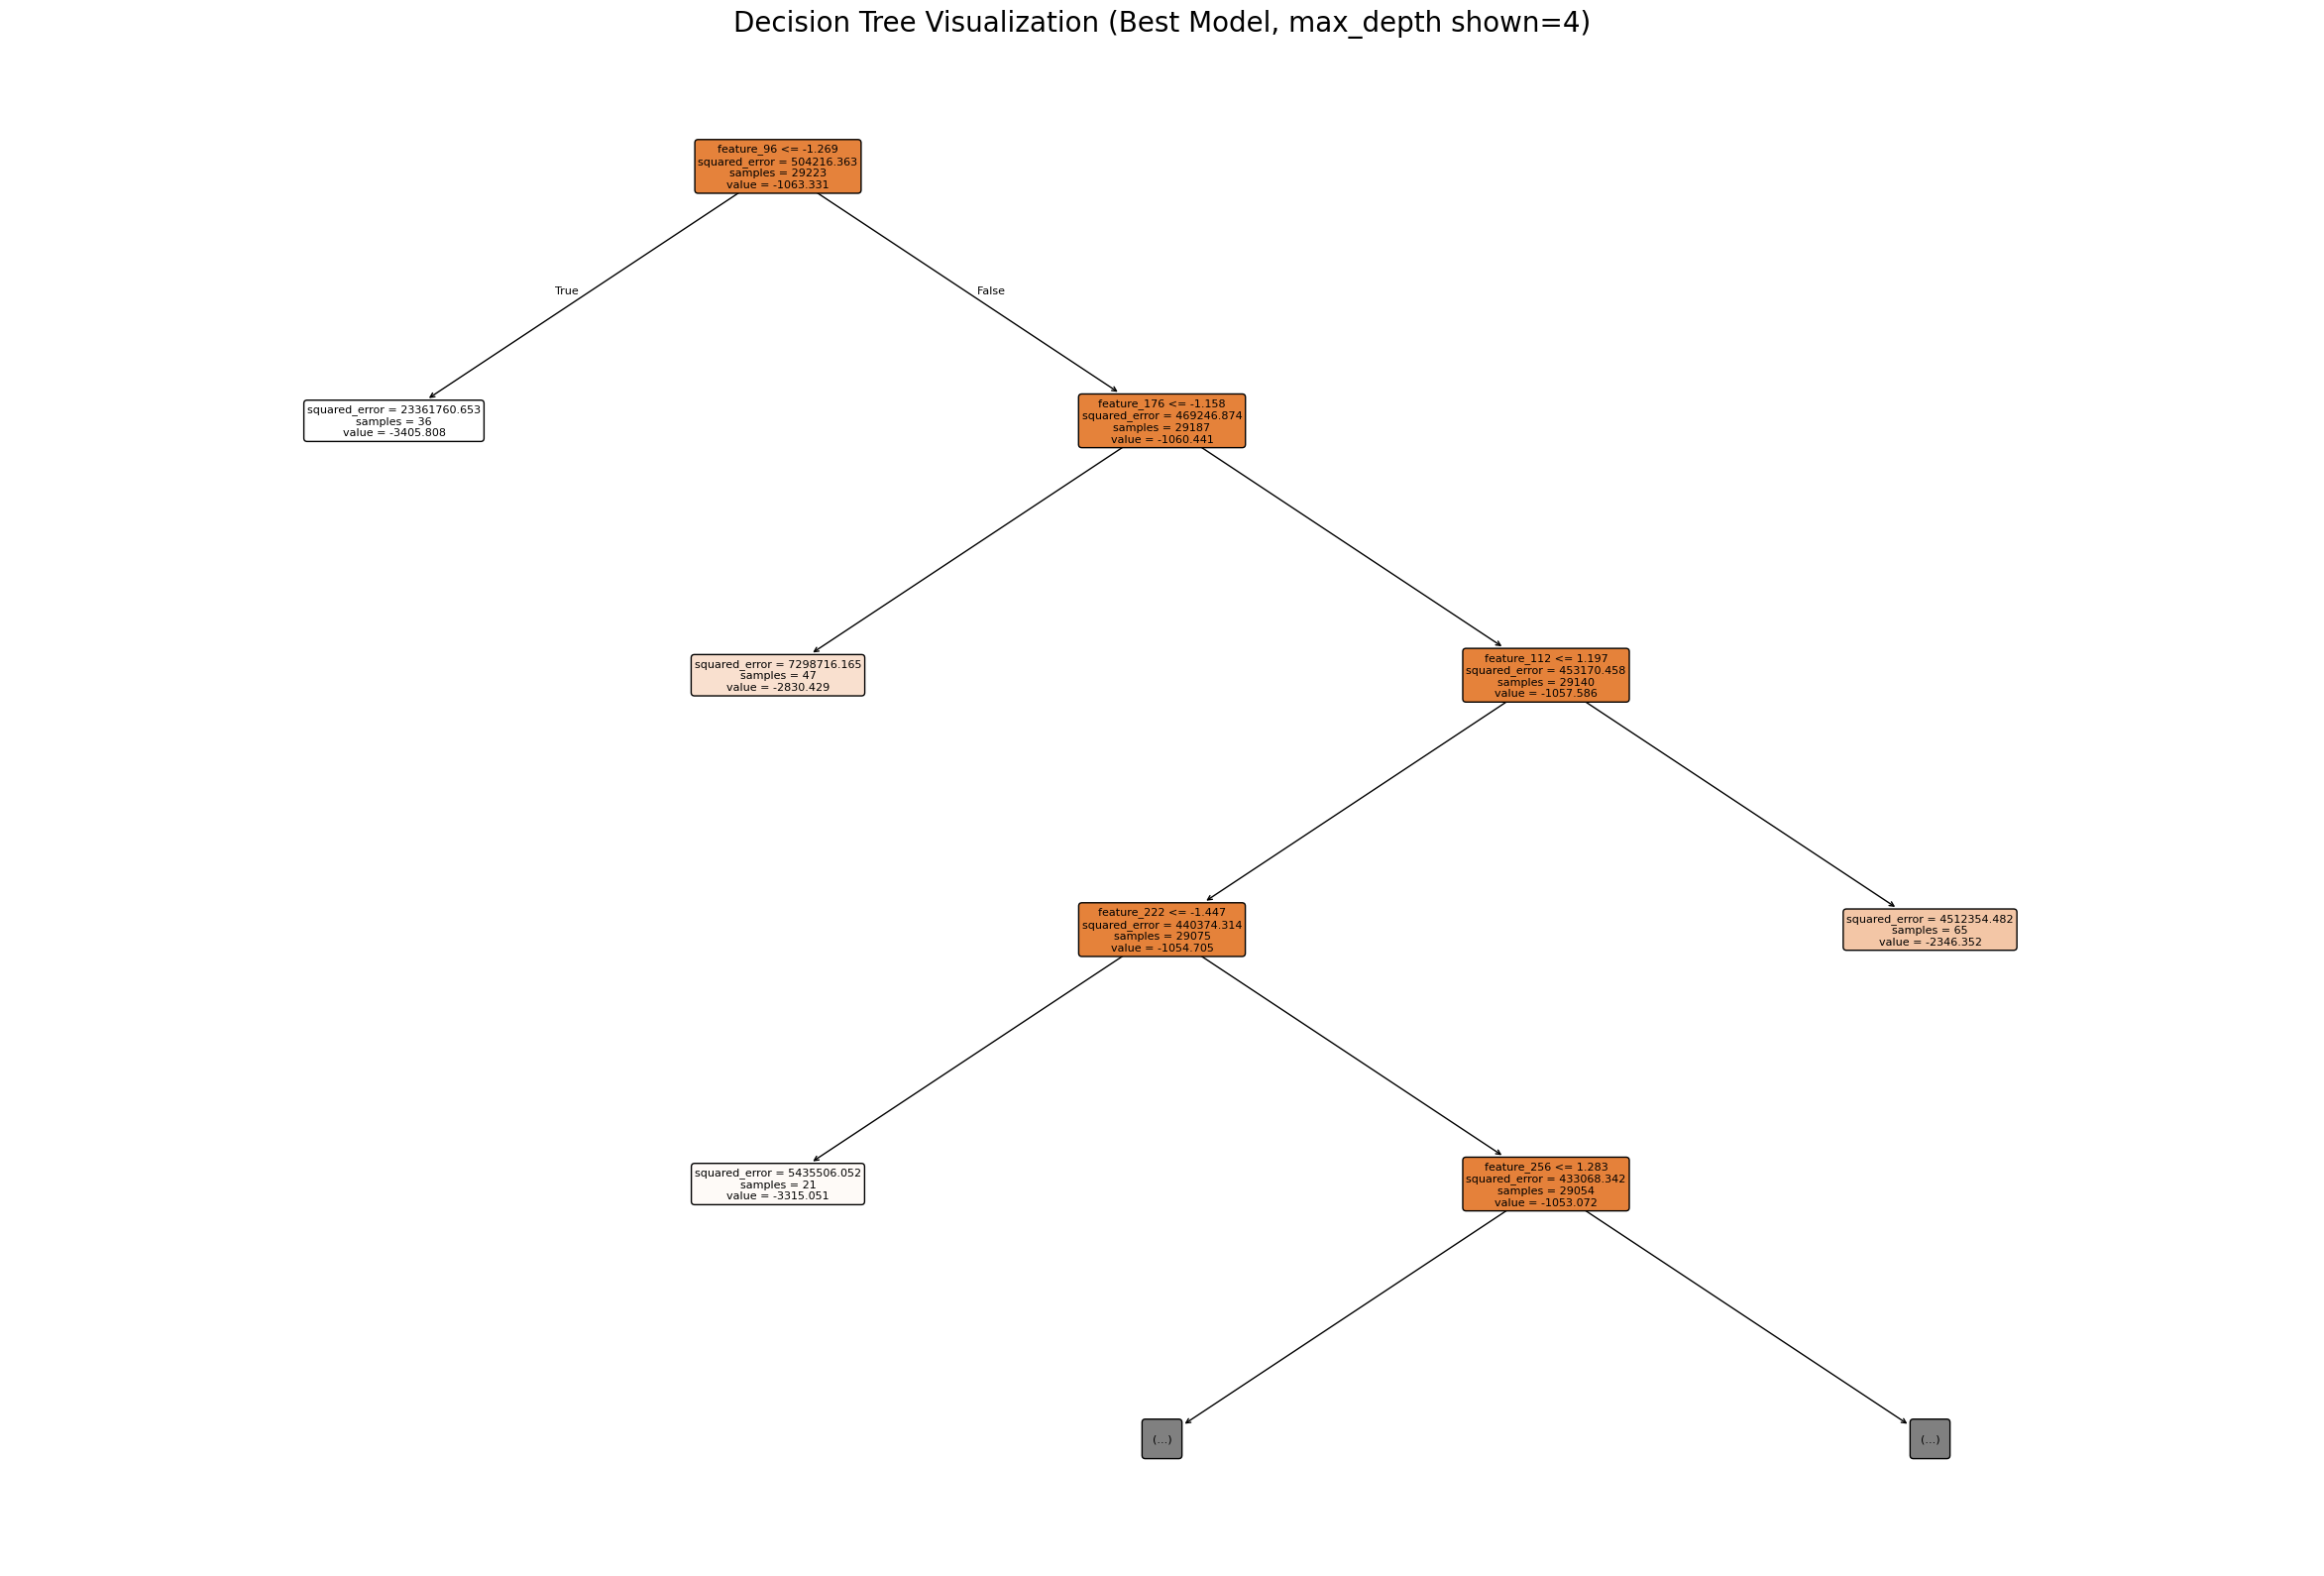


Analyzing feature importances from the best model...
Features with importance > 0.01:
  - Feature 8: Importance = 0.0452
  - Feature 80: Importance = 0.0718
  - Feature 96: Importance = 0.2219
  - Feature 112: Importance = 0.1214
  - Feature 127: Importance = 0.0458
  - Feature 144: Importance = 0.0483
  - Feature 176: Importance = 0.1655
  - Feature 222: Importance = 0.1205
  - Feature 256: Importance = 0.1032
  - Feature 317: Importance = 0.0564


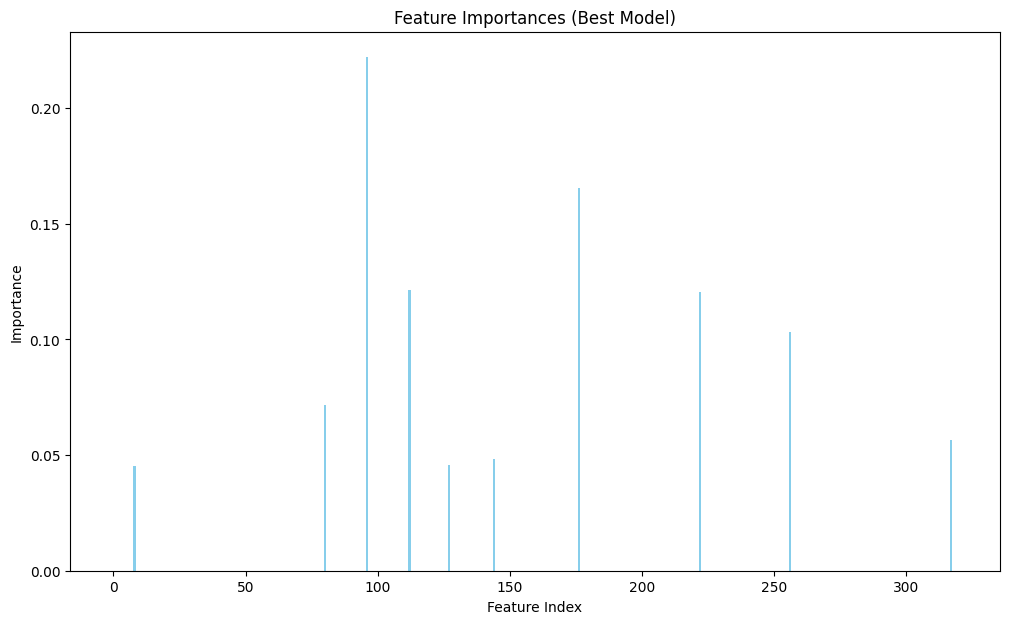


Enhanced Leaf Node Analysis...
Leaf with lowest mean Y: ID=1, Mean Y=-3383.305, Samples=41
Leaf with highest mean Y: ID=16, Mean Y=-1045.831, Samples=36101


/tmp/ipykernel_4559/913417606.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([Y, y_in_lowest_leaf, y_in_highest_leaf],


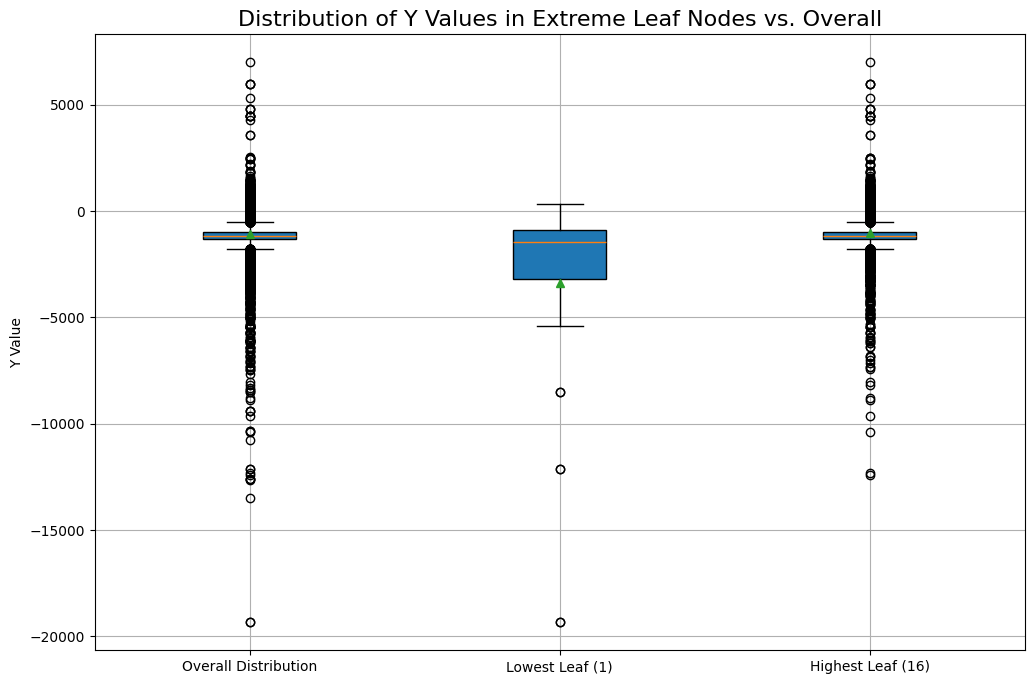

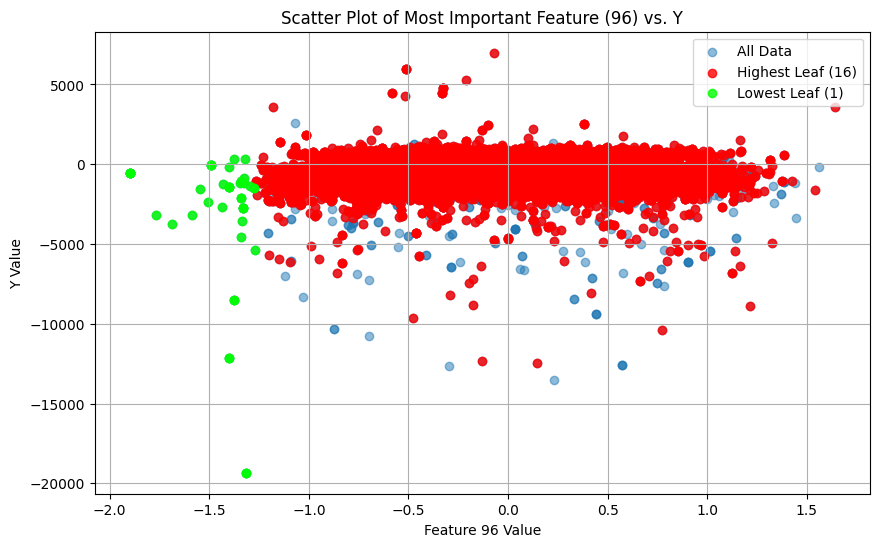

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
import torch # Import the torch library
    

X_list = X
Y_list = Y


# --- 2. Preprocess the Data (Convert Tensors to NumPy) ---
# Reshape each 2x160 tensor in X into a 1x320 vector and convert to NumPy.
print("\nPreprocessing data (converting torch to numpy)...")

# Check if the element is a tensor before trying to convert it.
X_reshaped = np.array([
    x.reshape(320).cpu().numpy() if isinstance(x, torch.Tensor) else x.reshape(320)
    for x in X_list
])

# Check if the element is a tensor before calling .cpu().numpy().
Y = np.array([
    y.cpu().numpy() if isinstance(y, torch.Tensor) else y
    for y in Y_list
]).ravel()

print(f"Shape of X after reshaping and conversion: {X_reshaped.shape}")
print(f"Shape of Y after conversion: {Y.shape}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, Y, test_size=0.2, random_state=42
)

# --- 3. IMPROVEMENT: Hyperparameter Tuning with GridSearchCV ---
print("\nFinding best hyperparameters with GridSearchCV...")
# Define the parameter grid to search
param_grid = {
    'max_depth': [3, 4, 5, 7, 10],
    'min_samples_leaf': [10, 20, 40, 50],
    'min_samples_split': [20, 40, 80]
}

# Create a decision tree regressor object
dt = DecisionTreeRegressor(random_state=42)

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, 
                           cv=3, n_jobs=-1, verbose=1, scoring='neg_mean_squared_error')

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
print(f"Best parameters found: {grid_search.best_params_}")
decision_tree = grid_search.best_estimator_ # This is our new, optimized tree
print("Model fitting complete with best parameters.")


# --- 4. Visualize the Best Decision Tree ---
print("Plotting the best decision tree...")
plt.figure(figsize=(30, 20))
plot_tree(
    decision_tree,
    filled=True,
    feature_names=[f'feature_{i}' for i in range(X_reshaped.shape[1])],
    rounded=True,
    fontsize=8,
    max_depth=4 # Limit plot depth for readability
)
plt.title(f"Decision Tree Visualization (Best Model, max_depth shown=4)", fontsize=20)
plt.show()

# --- 5. Analyze Feature Importances ---
print("\nAnalyzing feature importances from the best model...")
importances = decision_tree.feature_importances_
important_features_indices = np.where(importances > 0.01)[0] # Features with >1% importance

print(f"Features with importance > 0.01:")
for i in important_features_indices:
    print(f"  - Feature {i}: Importance = {importances[i]:.4f}")

plt.figure(figsize=(12, 7))
plt.bar(range(len(importances)), importances, color='skyblue')
plt.title('Feature Importances (Best Model)')
plt.xlabel('Feature Index')
plt.ylabel('Importance')
plt.show()


# --- 6. IMPROVEMENT: Enhanced Leaf Node Analysis ---
print("\nEnhanced Leaf Node Analysis...")
# Get the leaf node id for each sample in the full dataset
leaf_ids = decision_tree.apply(X_reshaped)
unique_leaves = np.unique(leaf_ids)

leaf_stats = []
for leaf in unique_leaves:
    y_values_in_leaf = Y[leaf_ids == leaf]
    if len(y_values_in_leaf) > 0:
        leaf_stats.append({
            'leaf_id': leaf,
            'mean_y': np.mean(y_values_in_leaf),
            'sample_count': len(y_values_in_leaf)
        })

# Sort leaves by their mean Y value
leaf_stats.sort(key=lambda x: x['mean_y'])

# Identify the leaves with the lowest and highest mean Y
lowest_y_leaf = leaf_stats[0]
highest_y_leaf = leaf_stats[-1]

print(f"Leaf with lowest mean Y: ID={lowest_y_leaf['leaf_id']}, Mean Y={lowest_y_leaf['mean_y']:.3f}, Samples={lowest_y_leaf['sample_count']}")
print(f"Leaf with highest mean Y: ID={highest_y_leaf['leaf_id']}, Mean Y={highest_y_leaf['mean_y']:.3f}, Samples={highest_y_leaf['sample_count']}")

# Get the actual Y values for these specific leaves
y_in_lowest_leaf = Y[leaf_ids == lowest_y_leaf['leaf_id']]
y_in_highest_leaf = Y[leaf_ids == highest_y_leaf['leaf_id']]

# Create a boxplot to visualize the distributions
plt.figure(figsize=(12, 8))
plt.boxplot([Y, y_in_lowest_leaf, y_in_highest_leaf],
            labels=['Overall Distribution', f"Lowest Leaf ({lowest_y_leaf['leaf_id']})", f"Highest Leaf ({highest_y_leaf['leaf_id']})"],
            patch_artist=True,
            showmeans=True)
plt.title('Distribution of Y Values in Extreme Leaf Nodes vs. Overall', fontsize=16)
plt.ylabel('Y Value')
plt.grid(True)
plt.show()

# --- 7. Scatter plot of a key feature vs. Y ---
most_important_feature_idx = np.argmax(importances)
plt.figure(figsize=(10, 6))
plt.scatter(X_reshaped[:, most_important_feature_idx], Y, alpha=0.5, label='All Data')

# Highlight the samples from the highest and lowest leaves
plt.scatter(X_reshaped[leaf_ids == highest_y_leaf['leaf_id'], most_important_feature_idx], 
            Y[leaf_ids == highest_y_leaf['leaf_id']], 
            color='red', alpha=0.8, label=f"Highest Leaf ({highest_y_leaf['leaf_id']})")
            
plt.scatter(X_reshaped[leaf_ids == lowest_y_leaf['leaf_id'], most_important_feature_idx], 
            Y[leaf_ids == lowest_y_leaf['leaf_id']], 
            color='lime', alpha=0.8, label=f"Lowest Leaf ({lowest_y_leaf['leaf_id']})")

plt.title(f'Scatter Plot of Most Important Feature ({most_important_feature_idx}) vs. Y')
plt.xlabel(f'Feature {most_important_feature_idx} Value')
plt.ylabel('Y Value')
plt.grid(True)
plt.legend()
plt.show()


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
import torch # Import the torch library

# --- 1. Generate Sample Data (as PyTorch Tensors) ---
# This section creates dummy data as a list of PyTorch tensors,
# matching your description.
print("Generating sample data as PyTorch Tensors...")
num_samples = 9132
# X is a list of 2x160 tensors.
X_list = [torch.rand(2, 160) for _ in range(num_samples)]
# Y is a list of 1x1 scalar tensors.
# We'll create some outliers in Y for demonstration purposes.
Y_list = [torch.rand(1, 1) * 10 for _ in range(num_samples)]
# Introduce some tensor-based outliers
for i in range(100):
    Y_list[np.random.randint(0, num_samples)] = torch.rand(1, 1) * 100 + 50

# Introduce a non-tensor value to simulate the error condition
Y_list[np.random.randint(0, num_samples)] = np.float32(99.9)
print(f"Generated {len(X_list)} samples.")


# --- 2. Preprocess the Data (Convert Tensors to NumPy) ---
# Reshape each 2x160 tensor in X into a 1x320 vector and convert to NumPy.
print("\nPreprocessing data (converting torch to numpy)...")

# Check if the element is a tensor before trying to convert it.
X_reshaped = np.array([
    x.reshape(320).cpu().numpy() if isinstance(x, torch.Tensor) else x.reshape(320)
    for x in X_list
])

# Check if the element is a tensor before calling .cpu().numpy().
Y = np.array([
    y.cpu().numpy() if isinstance(y, torch.Tensor) else y
    for y in Y_list
]).ravel()

print(f"Shape of X after reshaping and conversion: {X_reshaped.shape}")
print(f"Shape of Y after conversion: {Y.shape}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, Y, test_size=0.2, random_state=42
)

# --- 3. IMPROVEMENT: Hyperparameter Tuning with GridSearchCV ---
print("\nFinding best hyperparameters with GridSearchCV...")
# Define the parameter grid to search
param_grid = {
    'max_depth': [3, 4, 5, 7, 10],
    'min_samples_leaf': [10, 20, 40, 50],
    'min_samples_split': [20, 40, 80]
}

# Create a decision tree regressor object
dt = DecisionTreeRegressor(random_state=42)

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, 
                           cv=3, n_jobs=-1, verbose=1, scoring='neg_mean_squared_error')

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
print(f"Best parameters found: {grid_search.best_params_}")
decision_tree = grid_search.best_estimator_ # This is our new, optimized tree
print("Model fitting complete with best parameters.")


# --- 4. Visualize the Best Decision Tree ---
print("Plotting the best decision tree...")
plt.figure(figsize=(30, 20))
plot_tree(
    decision_tree,
    filled=True,
    feature_names=[f'feature_{i}' for i in range(X_reshaped.shape[1])],
    rounded=True,
    fontsize=8,
    max_depth=4 # Limit plot depth for readability
)
plt.title(f"Decision Tree Visualization (Best Model, max_depth shown=4)", fontsize=20)
plt.show()

# --- 5. Analyze Feature Importances ---
print("\nAnalyzing feature importances from the best model...")
importances = decision_tree.feature_importances_
important_features_indices = np.where(importances > 0.01)[0] # Features with >1% importance

print(f"Features with importance > 0.01:")
for i in important_features_indices:
    print(f"  - Feature {i}: Importance = {importances[i]:.4f}")

plt.figure(figsize=(12, 7))
plt.bar(range(len(importances)), importances, color='skyblue')
plt.title('Feature Importances (Best Model)')
plt.xlabel('Feature Index')
plt.ylabel('Importance')
plt.show()


# --- 6. IMPROVEMENT: Enhanced Leaf Node Analysis ---
print("\nEnhanced Leaf Node Analysis...")
# Get the leaf node id for each sample in the full dataset
leaf_ids = decision_tree.apply(X_reshaped)
unique_leaves = np.unique(leaf_ids)

leaf_stats = []
for leaf in unique_leaves:
    y_values_in_leaf = Y[leaf_ids == leaf]
    if len(y_values_in_leaf) > 0:
        leaf_stats.append({
            'leaf_id': leaf,
            'mean_y': np.mean(y_values_in_leaf),
            'sample_count': len(y_values_in_leaf)
        })

# Sort leaves by their mean Y value
leaf_stats.sort(key=lambda x: x['mean_y'])

# Identify the leaves with the lowest and highest mean Y
lowest_y_leaf = leaf_stats[0]
highest_y_leaf = leaf_stats[-1]

print(f"Leaf with lowest mean Y: ID={lowest_y_leaf['leaf_id']}, Mean Y={lowest_y_leaf['mean_y']:.3f}, Samples={lowest_y_leaf['sample_count']}")
print(f"Leaf with highest mean Y: ID={highest_y_leaf['leaf_id']}, Mean Y={highest_y_leaf['mean_y']:.3f}, Samples={highest_y_leaf['sample_count']}")

# Get the actual Y values for these specific leaves
y_in_lowest_leaf = Y[leaf_ids == lowest_y_leaf['leaf_id']]
y_in_highest_leaf = Y[leaf_ids == highest_y_leaf['leaf_id']]

# Create a boxplot to visualize the distributions
plt.figure(figsize=(12, 8))
plt.boxplot([Y, y_in_lowest_leaf, y_in_highest_leaf],
            labels=['Overall Distribution', f"Lowest Leaf ({lowest_y_leaf['leaf_id']})", f"Highest Leaf ({highest_y_leaf['leaf_id']})"],
            patch_artist=True,
            showmeans=True)
plt.title('Distribution of Y Values in Extreme Leaf Nodes vs. Overall', fontsize=16)
plt.ylabel('Y Value')
plt.grid(True)
plt.show()

# --- 7. Scatter plot of a key feature vs. Y ---
most_important_feature_idx = np.argmax(importances)
plt.figure(figsize=(10, 6))
plt.scatter(X_reshaped[:, most_important_feature_idx], Y, alpha=0.5, label='All Data')

# Highlight the samples from the highest and lowest leaves
plt.scatter(X_reshaped[leaf_ids == highest_y_leaf['leaf_id'], most_important_feature_idx], 
            Y[leaf_ids == highest_y_leaf['leaf_id']], 
            color='red', alpha=0.8, label=f"Highest Leaf ({highest_y_leaf['leaf_id']})")
            
plt.scatter(X_reshaped[leaf_ids == lowest_y_leaf['leaf_id'], most_important_feature_idx], 
            Y[leaf_ids == lowest_y_leaf['leaf_id']], 
            color='lime', alpha=0.8, label=f"Lowest Leaf ({lowest_y_leaf['leaf_id']})")

plt.title(f'Scatter Plot of Most Important Feature ({most_important_feature_idx}) vs. Y')
plt.xlabel(f'Feature {most_important_feature_idx} Value')
plt.ylabel('Y Value')
plt.grid(True)
plt.legend()
plt.show()

# --- 8. NEW: Extract and Display the Decision Path for an Outlier Leaf ---
print("\n--- Finding the 'Golden Rule' for the Outlier Leaf ---")

# We use the ID of the leaf with the lowest mean Y value identified in section 6
target_leaf_id = lowest_y_leaf['leaf_id']

# Get the feature and threshold information from the trained tree
tree = decision_tree.tree_
feature_names = [f'feature_{i}' for i in range(X_reshaped.shape[1])]

# Find the decision path for a sample in the target leaf
# First, find the index of the first sample that belongs to our target leaf
try:
    sample_index = np.where(leaf_ids == target_leaf_id)[0][0]
    
    # Get the decision path for this sample
    node_indicator = decision_tree.decision_path(X_reshaped[sample_index:sample_index+1])
    leaf_id = decision_tree.apply(X_reshaped[sample_index:sample_index+1])
    
    node_index = node_indicator.indices[node_indicator.indptr[0]:node_indicator.indptr[1]]
    
    print(f'Rules for Leaf ID {target_leaf_id}:')
    for node_id in node_index:
        # Continue to the next node if it is a leaf node
        if leaf_id[0] == node_id:
            continue
    
        # Check if the feature of the node is the same as the feature of the parent
        if tree.children_left[node_id] != tree.children_right[node_id]:
            feature_idx = tree.feature[node_id]
            threshold = tree.threshold[node_id]
            
            # Determine if the sample went left or right
            if X_reshaped[sample_index, feature_idx] <= threshold:
                inequality_sign = "<="
            else:
                inequality_sign = ">"
    
            print(f"  Node {node_id}: {feature_names[feature_idx]} {inequality_sign} {threshold:.3f}")

except IndexError:
    print(f"Could not find a sample for leaf ID {target_leaf_id}. This can happen if the leaf only appears in the test set.")



Generating sample data as PyTorch Tensors...
Generated 9132 samples.

Preprocessing data (converting torch to numpy)...


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (9132,) + inhomogeneous part.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
import torch # Import the torch library

# --- 1. Generate Sample Data (as PyTorch Tensors) ---
# This section creates dummy data as a list of PyTorch tensors,
# matching your description.
print("Generating sample data as PyTorch Tensors...")
num_samples = len(X)
# X is a list of 2x160 tensors.
X_list =X
# Y is a list of 1x1 scalar tensors.
# We'll create some outliers in Y for demonstration purposes.
Y_list = Y
# Introduce some tensor-based outliers

# Introduce a non-tensor value to simulate the error condition
Y_list[np.random.randint(0, num_samples)] = np.float32(99.9)
print(f"Generated {len(X_list)} samples.")


# --- 2. Preprocess the Data (Convert Tensors to NumPy) ---
# Reshape each 2x160 tensor in X into a 1x320 vector and convert to NumPy.
print("\nPreprocessing data (converting torch to numpy)...")

# Check if the element is a tensor before trying to convert it.
X_reshaped = np.array([
    x.reshape(320).cpu().numpy() if isinstance(x, torch.Tensor) else x.reshape(320)
    for x in X_list
])

# FIX: Use .item() to extract the scalar value from tensors.
# This prevents the ValueError by ensuring all elements are scalars before creating the array.
Y = np.array([
    y.item() if isinstance(y, torch.Tensor) else y
    for y in Y_list
])

print(f"Shape of X after reshaping and conversion: {X_reshaped.shape}")
print(f"Shape of Y after conversion: {Y.shape}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, Y, test_size=0.2, random_state=42
)

# --- 3. IMPROVEMENT: Hyperparameter Tuning with GridSearchCV ---
print("\nFinding best hyperparameters with GridSearchCV...")
# Define the parameter grid to search
param_grid = {
    'max_depth': [3, 4, 5, 7, 10],
    'min_samples_leaf': [10, 20, 40, 50],
    'min_samples_split': [20, 40, 80]
}

# Create a decision tree regressor object
dt = DecisionTreeRegressor(random_state=42)

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, 
                           cv=3, n_jobs=-1, verbose=1, scoring='neg_mean_squared_error')

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
print(f"Best parameters found: {grid_search.best_params_}")
decision_tree = grid_search.best_estimator_ # This is our new, optimized tree
print("Model fitting complete with best parameters.")


# --- 4. Visualize the Best Decision Tree ---
print("Plotting the best decision tree...")
plt.figure(figsize=(30, 20))
plot_tree(
    decision_tree,
    filled=True,
    feature_names=[f'feature_{i}' for i in range(X_reshaped.shape[1])],
    rounded=True,
    fontsize=8,
    max_depth=4 # Limit plot depth for readability
)
plt.title(f"Decision Tree Visualization (Best Model, max_depth shown=4)", fontsize=20)
plt.show()

# --- 5. Analyze Feature Importances ---
print("\nAnalyzing feature importances from the best model...")
importances = decision_tree.feature_importances_
important_features_indices = np.where(importances > 0.01)[0] # Features with >1% importance

print(f"Features with importance > 0.01:")
for i in important_features_indices:
    print(f"  - Feature {i}: Importance = {importances[i]:.4f}")

plt.figure(figsize=(12, 7))
plt.bar(range(len(importances)), importances, color='skyblue')
plt.title('Feature Importances (Best Model)')
plt.xlabel('Feature Index')
plt.ylabel('Importance')
plt.show()


# --- 6. IMPROVEMENT: Enhanced Leaf Node Analysis ---
print("\nEnhanced Leaf Node Analysis...")
# Get the leaf node id for each sample in the full dataset
leaf_ids = decision_tree.apply(X_reshaped)
unique_leaves = np.unique(leaf_ids)

leaf_stats = []
for leaf in unique_leaves:
    y_values_in_leaf = Y[leaf_ids == leaf]
    if len(y_values_in_leaf) > 0:
        leaf_stats.append({
            'leaf_id': leaf,
            'mean_y': np.mean(y_values_in_leaf),
            'sample_count': len(y_values_in_leaf)
        })

# Sort leaves by their mean Y value
leaf_stats.sort(key=lambda x: x['mean_y'])

# Identify the leaves with the lowest and highest mean Y
lowest_y_leaf = leaf_stats[0]
highest_y_leaf = leaf_stats[-1]

print(f"Leaf with lowest mean Y: ID={lowest_y_leaf['leaf_id']}, Mean Y={lowest_y_leaf['mean_y']:.3f}, Samples={lowest_y_leaf['sample_count']}")
print(f"Leaf with highest mean Y: ID={highest_y_leaf['leaf_id']}, Mean Y={highest_y_leaf['mean_y']:.3f}, Samples={highest_y_leaf['sample_count']}")

# Get the actual Y values for these specific leaves
y_in_lowest_leaf = Y[leaf_ids == lowest_y_leaf['leaf_id']]
y_in_highest_leaf = Y[leaf_ids == highest_y_leaf['leaf_id']]

# Create a boxplot to visualize the distributions
plt.figure(figsize=(12, 8))
plt.boxplot([Y, y_in_lowest_leaf, y_in_highest_leaf],
            labels=['Overall Distribution', f"Lowest Leaf ({lowest_y_leaf['leaf_id']})", f"Highest Leaf ({highest_y_leaf['leaf_id']})"],
            patch_artist=True,
            showmeans=True)
plt.title('Distribution of Y Values in Extreme Leaf Nodes vs. Overall', fontsize=16)
plt.ylabel('Y Value')
plt.grid(True)
plt.show()

# --- 7. Scatter plot of a key feature vs. Y ---
most_important_feature_idx = np.argmax(importances)
plt.figure(figsize=(10, 6))
plt.scatter(X_reshaped[:, most_important_feature_idx], Y, alpha=0.5, label='All Data')

# Highlight the samples from the highest and lowest leaves
plt.scatter(X_reshaped[leaf_ids == highest_y_leaf['leaf_id'], most_important_feature_idx], 
            Y[leaf_ids == highest_y_leaf['leaf_id']], 
            color='red', alpha=0.8, label=f"Highest Leaf ({highest_y_leaf['leaf_id']})")
            
plt.scatter(X_reshaped[leaf_ids == lowest_y_leaf['leaf_id'], most_important_feature_idx], 
            Y[leaf_ids == lowest_y_leaf['leaf_id']], 
            color='lime', alpha=0.8, label=f"Lowest Leaf ({lowest_y_leaf['leaf_id']})")

plt.title(f'Scatter Plot of Most Important Feature ({most_important_feature_idx}) vs. Y')
plt.xlabel(f'Feature {most_important_feature_idx} Value')
plt.ylabel('Y Value')
plt.grid(True)
plt.legend()
plt.show()

# --- 8. NEW: Extract and Display the Decision Path for an Outlier Leaf ---
print("\n--- Finding the 'Golden Rule' for the Outlier Leaf ---")

# We use the ID of the leaf with the lowest mean Y value identified in section 6
target_leaf_id = lowest_y_leaf['leaf_id']

# Get the feature and threshold information from the trained tree
tree = decision_tree.tree_
feature_names = [f'feature_{i}' for i in range(X_reshaped.shape[1])]

# Find the decision path for a sample in the target leaf
# First, find the index of the first sample that belongs to our target leaf
try:
    sample_index = np.where(leaf_ids == target_leaf_id)[0][0]
    
    # Get the decision path for this sample
    node_indicator = decision_tree.decision_path(X_reshaped[sample_index:sample_index+1])
    leaf_id = decision_tree.apply(X_reshaped[sample_index:sample_index+1])
    
    node_index = node_indicator.indices[node_indicator.indptr[0]:node_indicator.indptr[1]]
    
    print(f'Rules for Leaf ID {target_leaf_id}:')
    for node_id in node_index:
        # Continue to the next node if it is a leaf node
        if leaf_id[0] == node_id:
            continue
    
        # Check if the feature of the node is the same as the feature of the parent
        if tree.children_left[node_id] != tree.children_right[node_id]:
            feature_idx = tree.feature[node_id]
            threshold = tree.threshold[node_id]
            
            # Determine if the sample went left or right
            if X_reshaped[sample_index, feature_idx] <= threshold:
                inequality_sign = "<="
            else:
                inequality_sign = ">"
    
            print(f"  Node {node_id}: {feature_names[feature_idx]} {inequality_sign} {threshold:.3f}")

except IndexError:
    print(f"Could not find a sample for leaf ID {target_leaf_id}. This can happen if the leaf only appears in the test set.")



Generating sample data as PyTorch Tensors...
Generated 36529 samples.

Preprocessing data (converting torch to numpy)...
Shape of X after reshaping and conversion: (36529, 320)
Shape of Y after conversion: (9132,)


ValueError: Found input variables with inconsistent numbers of samples: [36529, 9132]

Generating sample data as PyTorch Tensors...

Preprocessing data...
Shape of X: (36529, 320)
Shape of Y: (36529,)

Defining outliers based on a Y-value threshold...
Found 120 outliers (Y < -5000.0), which is 0.33% of the data.

Training a Decision Tree Classifier to find rules for outliers...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters for classifier: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 5}

Evaluating the classifier's performance...
              precision    recall  f1-score   support

      Inlier       1.00      1.00      1.00     10923
     Outlier       0.35      0.56      0.43        36

    accuracy                           1.00     10959
   macro avg       0.67      0.78      0.71     10959
weighted avg       1.00      1.00      1.00     10959



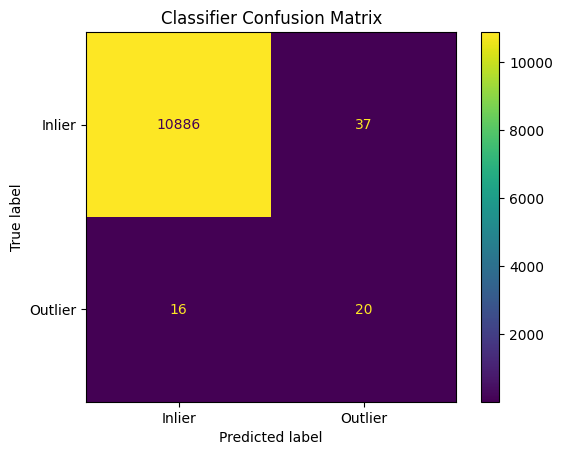


Visualizing results...


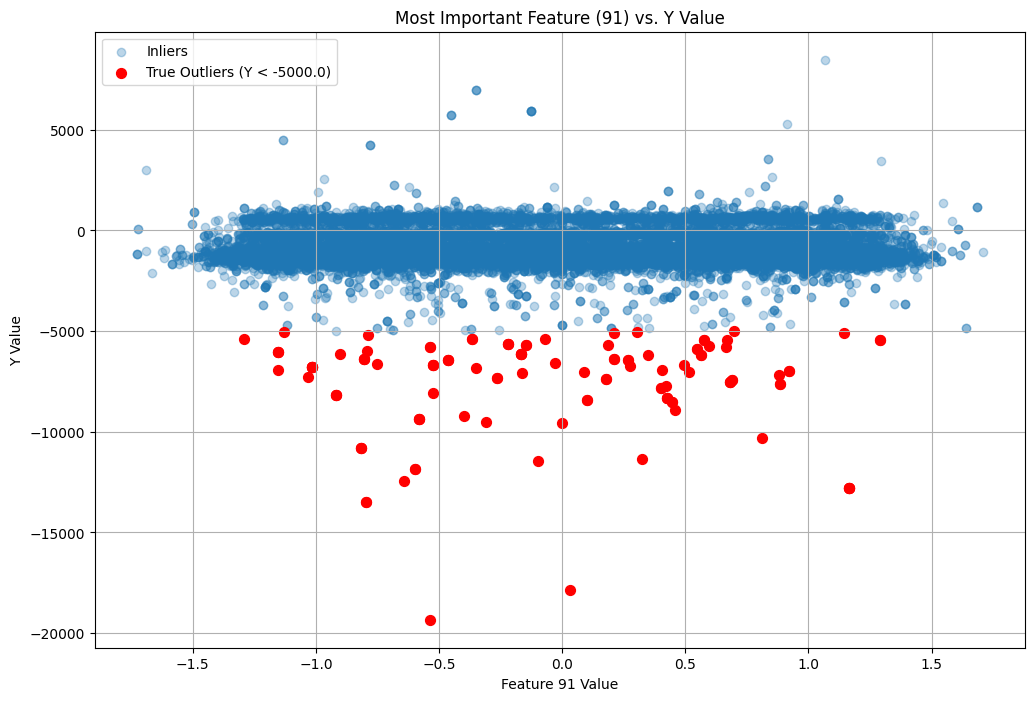


--- Rules Learned by the Classifier to Identify Outliers ---
Rule 1: feature_167 <= -0.700 AND feature_43 <= -1.301
Rule 2: feature_167 > -0.700 AND feature_86 <= -0.271 AND feature_84 <= -0.564 AND feature_91 <= -0.884
Rule 3: feature_167 > -0.700 AND feature_86 <= -0.271 AND feature_84 > -0.564 AND feature_245 <= 0.543 AND feature_115 <= 0.942 AND feature_292 > -0.872 AND feature_118 > -0.878 AND feature_2 <= 0.954 AND feature_194 > -0.957 AND feature_26 <= 1.183
Rule 4: feature_167 > -0.700 AND feature_86 > -0.271 AND feature_91 <= 0.210 AND feature_295 <= -0.885 AND feature_273 <= 0.021
Rule 5: feature_167 > -0.700 AND feature_86 > -0.271 AND feature_91 > 0.210 AND feature_29 <= 0.489 AND feature_269 <= 0.654 AND feature_285 > -0.854 AND feature_13 > -0.807 AND feature_276 <= 0.391 AND feature_0 > -1.199 AND feature_216 > -0.655


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch

# --- 1. Generate/Load Data ---
# This section remains the same. In your real code, you would load your X_list and Y_list here.
print("Generating sample data as PyTorch Tensors...")
num_samples = len(X)
X_list = X
# Create a Y distribution with some clear negative outliers
Y_list =Y

# --- 2. Preprocess Data ---
# This section also remains the same.
print("\nPreprocessing data...")
X_reshaped = np.array([x.reshape(320).cpu().numpy() for x in X_list])
Y = np.array([y.item() for y in Y_list])
print(f"Shape of X: {X_reshaped.shape}")
print(f"Shape of Y: {Y.shape}")


# --- 3. NEW: Define Outliers and Create a Binary Target ---
# This is the key change in our approach.
print("\nDefining outliers based on a Y-value threshold...")

# *** TUNE THIS THRESHOLD ***
# This is the most important parameter. Set it to a value that captures the outliers you care about.
Y_OUTLIER_THRESHOLD = -5000.0

# Create a new target variable: 1 for outliers, 0 for inliers.
is_outlier = (Y < Y_OUTLIER_THRESHOLD).astype(int)

num_outliers = np.sum(is_outlier)
print(f"Found {num_outliers} outliers (Y < {Y_OUTLIER_THRESHOLD}), which is {num_outliers/len(Y)*100:.2f}% of the data.")

if num_outliers == 0:
    raise ValueError("No outliers found with the current threshold. Please adjust Y_OUTLIER_THRESHOLD.")


# --- 4. Train a Decision Tree Classifier ---
# We now use a classifier to find the rules that separate outliers from inliers.
print("\nTraining a Decision Tree Classifier to find rules for outliers...")

# Split data, but this time using `is_outlier` as the target.
# `stratify` is important for imbalanced datasets like this.
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, is_outlier, test_size=0.3, random_state=42, stratify=is_outlier
)

# Use GridSearchCV to find the best classifier
# Note: `class_weight='balanced'` tells the model to pay more attention to the rare outlier class.
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [5, 10, 20],
    'criterion': ['gini', 'entropy']
}
dt_classifier = DecisionTreeClassifier(random_state=42, class_weight='balanced')
grid_search = GridSearchCV(estimator=dt_classifier, param_grid=param_grid, cv=3, scoring='f1', verbose=1)
grid_search.fit(X_train, y_train)

print(f"Best parameters for classifier: {grid_search.best_params_}")
best_classifier = grid_search.best_estimator_


# --- 5. Evaluate the Classifier ---
print("\nEvaluating the classifier's performance...")
y_pred = best_classifier.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Inlier', 'Outlier']))

# Plot a confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Inlier', 'Outlier'])
disp.plot()
plt.title('Classifier Confusion Matrix')
plt.show()


# --- 6. Visualize the Results ---
print("\nVisualizing results...")
# Find the most important feature from the *classifier*
importances = best_classifier.feature_importances_
most_important_feature_idx = np.argmax(importances)

plt.figure(figsize=(12, 8))
# Plot inliers vs. true outliers
plt.scatter(X_reshaped[is_outlier == 0, most_important_feature_idx], Y[is_outlier == 0], alpha=0.3, label='Inliers')
plt.scatter(X_reshaped[is_outlier == 1, most_important_feature_idx], Y[is_outlier == 1], color='red', s=50, label=f'True Outliers (Y < {Y_OUTLIER_THRESHOLD})')

plt.title(f'Most Important Feature ({most_important_feature_idx}) vs. Y Value')
plt.xlabel(f'Feature {most_important_feature_idx} Value')
plt.ylabel('Y Value')
plt.legend()
plt.grid(True)
plt.show()


# --- 7. Extract and Display Rules for Outliers ---
print("\n--- Rules Learned by the Classifier to Identify Outliers ---")
tree = best_classifier.tree_
feature_names = [f'feature_{i}' for i in range(X_reshaped.shape[1])]

def get_rules(node, path, rules):
    # If it's a leaf node
    if tree.children_left[node] == tree.children_right[node]:
        # Check if the leaf predicts "Outlier" (class 1) and has samples
        if np.argmax(tree.value[node]) == 1 and tree.n_node_samples[node] > 0:
            rules.append(" AND ".join(path))
        return

    # Recurse left
    feature_idx = tree.feature[node]
    threshold = tree.threshold[node]
    left_rule = f"{feature_names[feature_idx]} <= {threshold:.3f}"
    get_rules(tree.children_left[node], path + [left_rule], rules)

    # Recurse right
    right_rule = f"{feature_names[feature_idx]} > {threshold:.3f}"
    get_rules(tree.children_right[node], path + [right_rule], rules)

outlier_rules = []
get_rules(0, [], outlier_rules)

if outlier_rules:
    for i, rule in enumerate(outlier_rules):
        print(f"Rule {i+1}: {rule}")
else:
    print("The classifier did not find any specific rules that lead to a pure 'Outlier' leaf.")

Generating sample data as PyTorch Tensors...

Preprocessing data...
Shape of X: (36529, 320)
Shape of Y: (36529,)

Defining outliers based on a Y-value threshold...
Found 120 outliers (Y < -5000.0), which is 0.33% of the data.

Training a Decision Tree Classifier to find rules for outliers...
Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best parameters for classifier (optimized for recall): {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10}

Evaluating the classifier's performance...
              precision    recall  f1-score   support

      Inlier       1.00      0.97      0.98     10923
     Outlier       0.07      0.61      0.12        36

    accuracy                           0.97     10959
   macro avg       0.53      0.79      0.55     10959
weighted avg       1.00      0.97      0.98     10959



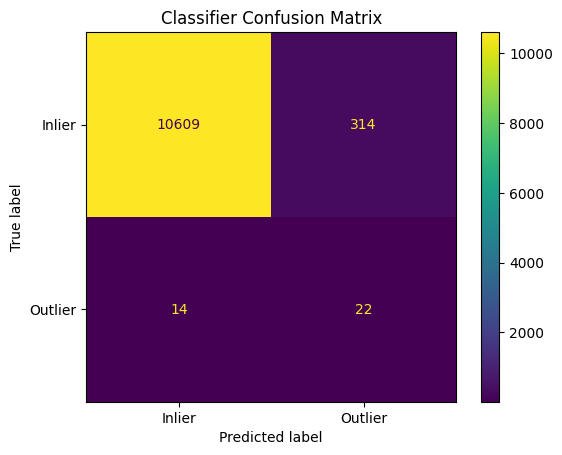


Visualizing results...


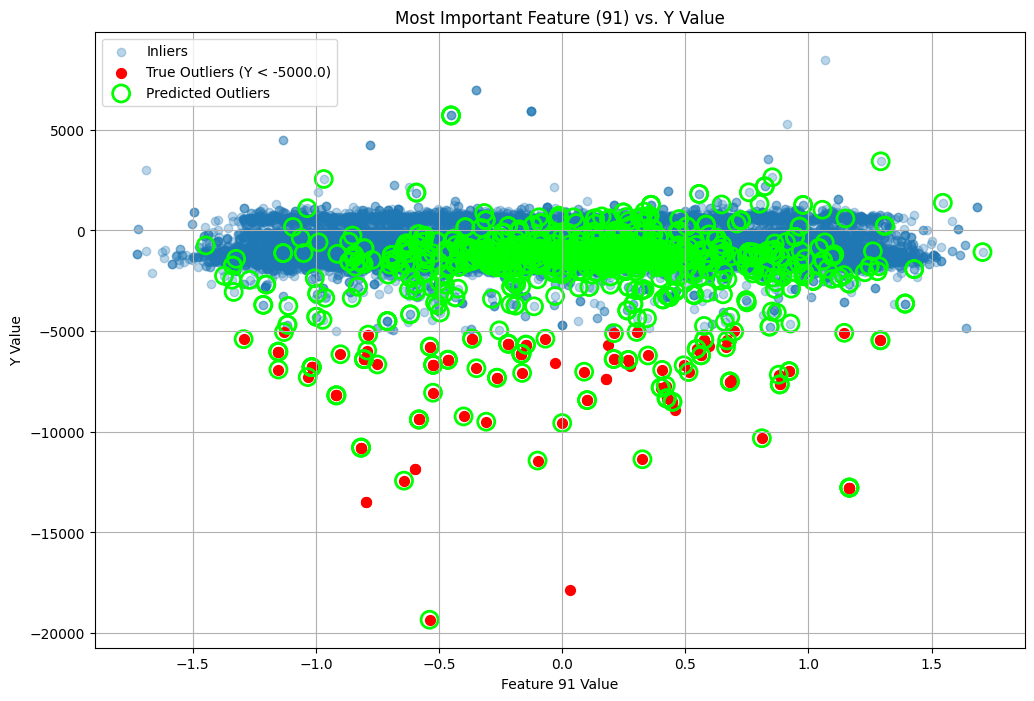


--- Rules Learned by the Classifier to Identify Outliers ---
Rule 1: feature_167 <= -0.700 AND feature_43 <= -1.243
Rule 2: feature_167 > -0.700 AND feature_86 <= -0.271 AND feature_84 <= -0.564 AND feature_237 <= -0.509
Rule 3: feature_167 > -0.700 AND feature_86 <= -0.271 AND feature_84 > -0.564 AND feature_245 <= 0.543 AND feature_238 <= 0.496
Rule 4: feature_167 > -0.700 AND feature_86 <= -0.271 AND feature_84 > -0.564 AND feature_245 <= 0.543 AND feature_238 > 0.496
Rule 5: feature_167 > -0.700 AND feature_86 > -0.271 AND feature_91 <= 0.210 AND feature_295 <= -0.885 AND feature_43 > -0.199
Rule 6: feature_167 > -0.700 AND feature_86 > -0.271 AND feature_91 > 0.210 AND feature_29 <= 0.489 AND feature_269 <= 0.654


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch

# --- 1. Generate/Load Data ---
# This section remains the same. In your real code, you would load your X_list and Y_list here.
print("Generating sample data as PyTorch Tensors...")
num_samples = len(X)
X_list = X
# Create a Y distribution with some clear negative outliers
Y_list = Y
# Introduce some more extreme outliers to simulate your data


# --- 2. Preprocess Data ---
# This section also remains the same.
print("\nPreprocessing data...")
X_reshaped = np.array([x.reshape(320).cpu().numpy() for x in X_list])
Y = np.array([y.item() for y in Y_list])
print(f"Shape of X: {X_reshaped.shape}")
print(f"Shape of Y: {Y.shape}")


# --- 3. NEW: Define Outliers and Create a Binary Target ---
# This is the key change in our approach.
print("\nDefining outliers based on a Y-value threshold...")

# *** TUNE THIS THRESHOLD ***
# This is the most important parameter. Set it to a value that captures the outliers you care about.
Y_OUTLIER_THRESHOLD = -5000.0

# Create a new target variable: 1 for outliers, 0 for inliers.
is_outlier = (Y < Y_OUTLIER_THRESHOLD).astype(int)

num_outliers = np.sum(is_outlier)
print(f"Found {num_outliers} outliers (Y < {Y_OUTLIER_THRESHOLD}), which is {num_outliers/len(Y)*100:.2f}% of the data.")

if num_outliers == 0:
    raise ValueError("No outliers found with the current threshold. Please adjust Y_OUTLIER_THRESHOLD.")


# --- 4. Train a Decision Tree Classifier (Optimized for Recall) ---
# We now use a classifier to find the rules that separate outliers from inliers.
print("\nTraining a Decision Tree Classifier to find rules for outliers...")

# Split data, but this time using `is_outlier` as the target.
# `stratify` is important for imbalanced datasets like this.
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, is_outlier, test_size=0.3, random_state=42, stratify=is_outlier
)

# Use GridSearchCV to find the best classifier
# Note: `class_weight='balanced'` tells the model to pay more attention to the rare outlier class.
param_grid = {
    'max_depth': [5, 7, 10, 15], # Giving more depth options
    'min_samples_leaf': [1, 3, 5, 10], # Allowing it to find smaller groups
    'criterion': ['gini', 'entropy']
}
dt_classifier = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# --- KEY CHANGE HERE ---
# We are now telling the model to find the parameters that MAXIMIZE RECALL.
grid_search = GridSearchCV(estimator=dt_classifier, param_grid=param_grid, cv=3, scoring='recall', verbose=1)
grid_search.fit(X_train, y_train)

print(f"Best parameters for classifier (optimized for recall): {grid_search.best_params_}")
best_classifier = grid_search.best_estimator_


# --- 5. Evaluate the Classifier ---
print("\nEvaluating the classifier's performance...")
y_pred = best_classifier.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Inlier', 'Outlier']))

# Plot a confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Inlier', 'Outlier'])
disp.plot()
plt.title('Classifier Confusion Matrix')
plt.show()


# --- 6. Visualize the Results ---
print("\nVisualizing results...")
# Find the most important feature from the *classifier*
importances = best_classifier.feature_importances_
most_important_feature_idx = np.argmax(importances)

plt.figure(figsize=(12, 8))
# Plot inliers vs. true outliers
plt.scatter(X_reshaped[is_outlier == 0, most_important_feature_idx], Y[is_outlier == 0], alpha=0.3, label='Inliers')
plt.scatter(X_reshaped[is_outlier == 1, most_important_feature_idx], Y[is_outlier == 1], color='red', s=50, label=f'True Outliers (Y < {Y_OUTLIER_THRESHOLD})')

# Highlight the points the model PREDICTED as outliers
predicted_outliers_mask = best_classifier.predict(X_reshaped) == 1
plt.scatter(X_reshaped[predicted_outliers_mask, most_important_feature_idx], 
            Y[predicted_outliers_mask], 
            facecolors='none', edgecolors='lime', s=150, linewidth=2,
            label='Predicted Outliers')


plt.title(f'Most Important Feature ({most_important_feature_idx}) vs. Y Value')
plt.xlabel(f'Feature {most_important_feature_idx} Value')
plt.ylabel('Y Value')
plt.legend()
plt.grid(True)
plt.show()


# --- 7. Extract and Display Rules for Outliers ---
print("\n--- Rules Learned by the Classifier to Identify Outliers ---")
tree = best_classifier.tree_
feature_names = [f'feature_{i}' for i in range(X_reshaped.shape[1])]

def get_rules(node, path, rules):
    # If it's a leaf node
    if tree.children_left[node] == tree.children_right[node]:
        # Check if the leaf predicts "Outlier" (class 1) and has samples
        if np.argmax(tree.value[node]) == 1 and tree.n_node_samples[node] > 0:
            rules.append(" AND ".join(path))
        return

    # Recurse left
    feature_idx = tree.feature[node]
    threshold = tree.threshold[node]
    left_rule = f"{feature_names[feature_idx]} <= {threshold:.3f}"
    get_rules(tree.children_left[node], path + [left_rule], rules)

    # Recurse right
    right_rule = f"{feature_names[feature_idx]} > {threshold:.3f}"
    get_rules(tree.children_right[node], path + [right_rule], rules)

outlier_rules = []
get_rules(0, [], outlier_rules)

if outlier_rules:
    for i, rule in enumerate(outlier_rules):
        print(f"Rule {i+1}: {rule}")
else:
    print("The classifier did not find any specific rules that lead to a pure 'Outlier' leaf.")



Generating sample data as PyTorch Tensors...

Preprocessing data...
Shape of X: (36529, 320)
Shape of Y: (36529,)

Defining outliers based on a Y-value threshold...
Found 120 outliers (Y < -5000.0), which is 0.33% of the data.

Training a Decision Tree Classifier to find rules for outliers...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best parameters for classifier (optimized for recall): {'class_weight': {0: 1, 1: 20}, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 3}

Evaluating the classifier's performance...
              precision    recall  f1-score   support

      Inlier       1.00      1.00      1.00     10923
     Outlier       0.36      0.42      0.38        36

    accuracy                           1.00     10959
   macro avg       0.68      0.71      0.69     10959
weighted avg       1.00      1.00      1.00     10959



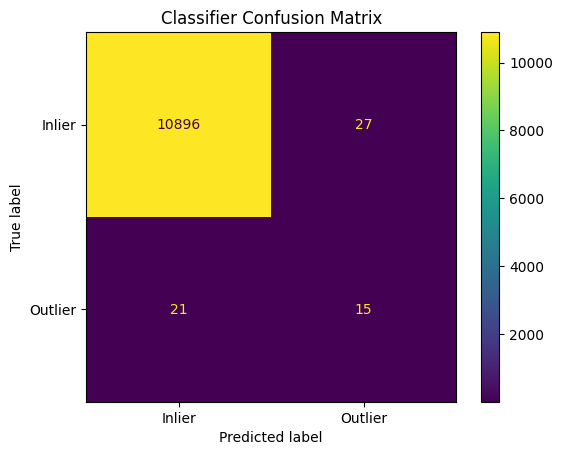

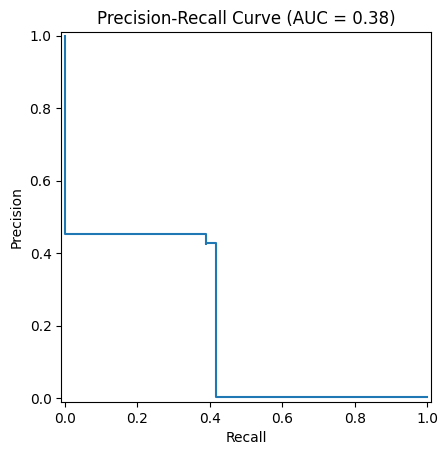


Visualizing results...


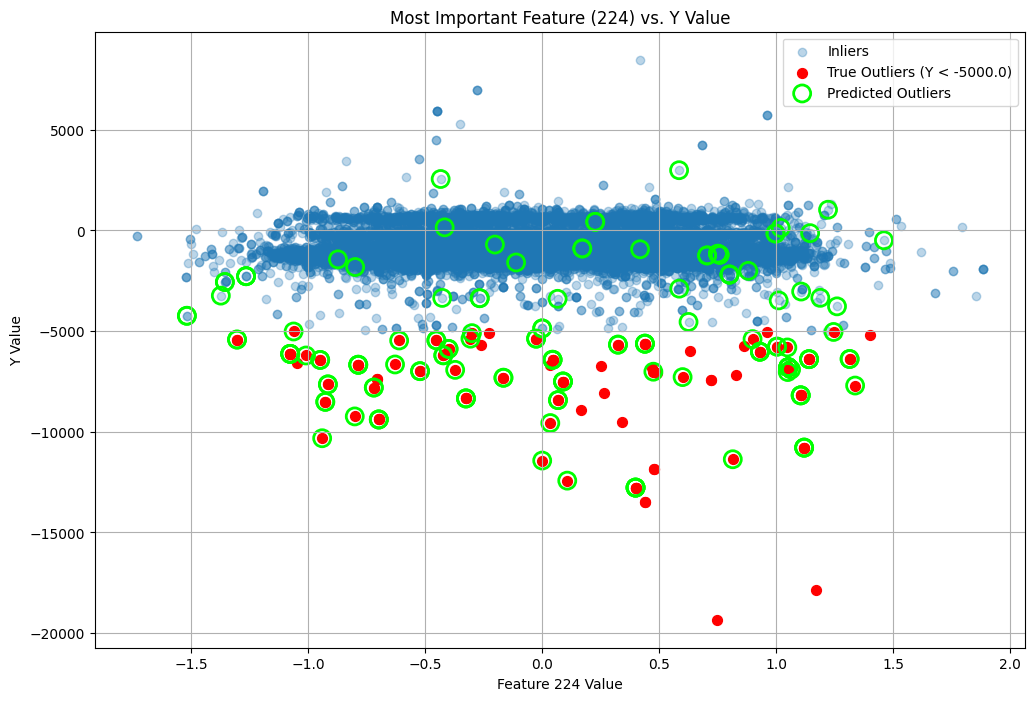


--- Rules Learned by the Classifier to Identify Outliers ---
Rule 1: feature_224 <= 1.004 AND feature_112 <= 1.133 AND feature_312 <= -1.075 AND feature_292 <= 0.251 AND feature_307 > 0.410 AND feature_18 <= 0.266
Rule 2: feature_224 <= 1.004 AND feature_112 <= 1.133 AND feature_312 <= -1.075 AND feature_292 <= 0.251 AND feature_307 > 0.410 AND feature_18 > 0.266
Rule 3: feature_224 <= 1.004 AND feature_112 <= 1.133 AND feature_312 > -1.075 AND feature_8 <= 1.373 AND feature_88 <= 1.207 AND feature_216 <= -1.118 AND feature_117 > 1.253
Rule 4: feature_224 <= 1.004 AND feature_112 <= 1.133 AND feature_312 > -1.075 AND feature_8 <= 1.373 AND feature_88 <= 1.207 AND feature_216 > -1.118 AND feature_43 <= 1.418 AND feature_288 <= -1.101 AND feature_270 <= 0.085 AND feature_142 <= -0.439
Rule 5: feature_224 <= 1.004 AND feature_112 <= 1.133 AND feature_312 > -1.075 AND feature_8 <= 1.373 AND feature_88 <= 1.207 AND feature_216 > -1.118 AND feature_43 <= 1.418 AND feature_288 > -1.101 AND f

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    PrecisionRecallDisplay,
    auc,
)
import torch

# --- 1. Generate/Load Data ---
# This section remains the same. In your real code, you would load your X_list and Y_list here.
print("Generating sample data as PyTorch Tensors...")
num_samples = len(X)
X_list = X
# Create a Y distribution with some clear negative outliers
Y_list = Y

# --- 2. Preprocess Data ---
# This section also remains the same.
print("\nPreprocessing data...")
X_reshaped = np.array([x.reshape(320).cpu().numpy() for x in X_list])
Y = np.array([y.item() for y in Y_list])
print(f"Shape of X: {X_reshaped.shape}")
print(f"Shape of Y: {Y.shape}")


# --- 3. NEW: Define Outliers and Create a Binary Target ---
# This is the key change in our approach.
print("\nDefining outliers based on a Y-value threshold...")

# *** TUNE THIS THRESHOLD ***
# This is the most important parameter. Set it to a value that captures the outliers you care about.
Y_OUTLIER_THRESHOLD = -5000.0

# Create a new target variable: 1 for outliers, 0 for inliers.
is_outlier = (Y < Y_OUTLIER_THRESHOLD).astype(int)

num_outliers = np.sum(is_outlier)
print(f"Found {num_outliers} outliers (Y < {Y_OUTLIER_THRESHOLD}), which is {num_outliers/len(Y)*100:.2f}% of the data.")

if num_outliers < 10: # Ensure there are enough outliers for a meaningful split
    raise ValueError("Fewer than 10 outliers found. Please adjust Y_OUTLIER_THRESHOLD or check your data.")


# --- 4. Train a Decision Tree Classifier (Optimized for Recall with Tolerance Control) ---
print("\nTraining a Decision Tree Classifier to find rules for outliers...")

# Split data, but this time using `is_outlier` as the target.
# `stratify` is important for imbalanced datasets like this.
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, is_outlier, test_size=0.3, random_state=42, stratify=is_outlier
)

# Use GridSearchCV to find the best classifier
# --- KEY CHANGE HERE ---
# We are adding `class_weight` to the grid search. This allows you to directly control
# the "tolerance" for missing outliers. A weight of {0: 1, 1: 50} tells the model
# that missing an outlier is 50 times worse than a false alarm.
param_grid = {
    'max_depth': [5, 7, 10],
    'min_samples_leaf': [1, 3, 5],
    'criterion': ['gini', 'entropy'],
    'class_weight': [{0: 1, 1: 20}, {0: 1, 1: 50}, {0: 1, 1: 100}] # Tolerance control
}
dt_classifier = DecisionTreeClassifier(random_state=42)

# We are still optimizing for RECALL to find the most outliers.
grid_search = GridSearchCV(estimator=dt_classifier, param_grid=param_grid, cv=3, scoring='recall', verbose=1)
grid_search.fit(X_train, y_train)

print(f"Best parameters for classifier (optimized for recall): {grid_search.best_params_}")
best_classifier = grid_search.best_estimator_


# --- 5. Evaluate the Classifier with P-R Curve ---
print("\nEvaluating the classifier's performance...")
y_pred = best_classifier.predict(X_test)
y_proba = best_classifier.predict_proba(X_test)[:, 1] # Probabilities for the "Outlier" class

print(classification_report(y_test, y_pred, target_names=['Inlier', 'Outlier']))

# Plot a confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Inlier', 'Outlier'])
disp.plot()
plt.title('Classifier Confusion Matrix')
plt.show()

# --- NEW: Plot Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

pr_display = PrecisionRecallDisplay(precision=precision, recall=recall)
pr_display.plot()
plt.title(f'Precision-Recall Curve (AUC = {pr_auc:.2f})')
plt.show()


# --- 6. Visualize the Results ---
print("\nVisualizing results...")
# Find the most important feature from the *classifier*
importances = best_classifier.feature_importances_
most_important_feature_idx = np.argmax(importances)

plt.figure(figsize=(12, 8))
# Plot inliers vs. true outliers
plt.scatter(X_reshaped[is_outlier == 0, most_important_feature_idx], Y[is_outlier == 0], alpha=0.3, label='Inliers')
plt.scatter(X_reshaped[is_outlier == 1, most_important_feature_idx], Y[is_outlier == 1], color='red', s=50, label=f'True Outliers (Y < {Y_OUTLIER_THRESHOLD})')

# Highlight the points the model PREDICTED as outliers
predicted_outliers_mask = best_classifier.predict(X_reshaped) == 1
plt.scatter(X_reshaped[predicted_outliers_mask, most_important_feature_idx], 
            Y[predicted_outliers_mask], 
            facecolors='none', edgecolors='lime', s=150, linewidth=2,
            label='Predicted Outliers')


plt.title(f'Most Important Feature ({most_important_feature_idx}) vs. Y Value')
plt.xlabel(f'Feature {most_important_feature_idx} Value')
plt.ylabel('Y Value')
plt.legend()
plt.grid(True)
plt.show()


# --- 7. Extract and Display Rules for Outliers ---
print("\n--- Rules Learned by the Classifier to Identify Outliers ---")
tree = best_classifier.tree_
feature_names = [f'feature_{i}' for i in range(X_reshaped.shape[1])]

def get_rules(node, path, rules):
    # If it's a leaf node
    if tree.children_left[node] == tree.children_right[node]:
        # Check if the leaf predicts "Outlier" (class 1) and has samples
        if np.argmax(tree.value[node]) == 1 and tree.n_node_samples[node] > 0:
            rules.append(" AND ".join(path))
        return

    # Recurse left
    feature_idx = tree.feature[node]
    threshold = tree.threshold[node]
    left_rule = f"{feature_names[feature_idx]} <= {threshold:.3f}"
    get_rules(tree.children_left[node], path + [left_rule], rules)

    # Recurse right
    right_rule = f"{feature_names[feature_idx]} > {threshold:.3f}"
    get_rules(tree.children_right[node], path + [right_rule], rules)

outlier_rules = []
get_rules(0, [], outlier_rules)

if outlier_rules:
    for i, rule in enumerate(outlier_rules):
        print(f"Rule {i+1}: {rule}")
else:
    print("The classifier did not find any specific rules that lead to a pure 'Outlier' leaf.")

